# **Project Name**

#### **House Price Prediction Using Machine Learning**


### **Name**
**Joel Richard. I**

## **Project Type**

**End-to-End Machine Learning Project (Supervised Learning – Regression)**


### **Contribution**
**Individual**


# **Project Summary**


>The project follows an **industry-standard ML pipeline**, ensuring reproducibility and scalability.

>Insights from **EDA, hypothesis testing, and feature importance** were aligned to validate data-driven decisions.

>**Robust evaluation** using multiple metrics minimized risk from large pricing errors.

>The final model is **deployment-ready**, enabling seamless integration into real-world applications.

>Clear documentation and clean code structure make the project **easy to maintain and extend**.

>The solution supports **business decision-making** by improving pricing accuracy, reducing risk, and increasing customer trust.


# **GitHub Link -**
>https://github.com/Richard-26/Heart-Disease-Prediction-ml.git

# **Problem Statement**

>Accurate estimation of house prices is a critical challenge in the real estate industry due to the influence of multiple factors such as property features, location, and overall quality. Manual pricing methods are often inconsistent and subjective, leading to pricing errors and financial risk.

>The objective of this project is to develop a **machine learning–based house price prediction model** that can accurately estimate property sale prices using historical data. By analyzing key features and building robust predictive models, the project aims to support data-driven decision-making, reduce pricing uncertainty, and provide reliable insights for real estate stakeholders.


# **General Guidelines** : -  

>Understand the dataset thoroughly before applying any machine learning techniques.

>Perform comprehensive **Exploratory Data Analysis (EDA)** to identify patterns, trends, and relationships.

>Clean and preprocess the data by handling missing values, outliers, and categorical variables appropriately.

>Apply feature engineering and feature selection to improve model performance.

> Use suitable evaluation metrics to measure model accuracy and business impact.

>Implement multiple machine learning models and compare their performance objectively.

>Apply cross-validation and hyperparameter tuning to enhance model generalization.

>Ensure the final model is interpretable and explainable.

>Validate the model using unseen data before deployment.

>Maintain clean, well-documented, and reproducible code throughout the project.

>Present insights and results clearly using professional visualizations and explanations.

>Focus on both **technical correctness** and **business relevance** in conclusions.


# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

%matplotlib inline
sns.set_style("whitegrid")


### Dataset Loading

In [109]:
# 2. Load Dataset
data = pd.read_csv('data.csv')
data.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Dataset First View

In [110]:
# Show first 5 rows
data.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Dataset Information


In [111]:
# Basic information about the dataset
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

#### Duplicate Values

In [112]:
# Check for duplicate values
duplicate_count = data.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)


Number of duplicate rows: 0


#### Missing Values/Null Values

In [113]:
# Check missing/null values in each column
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0])


LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


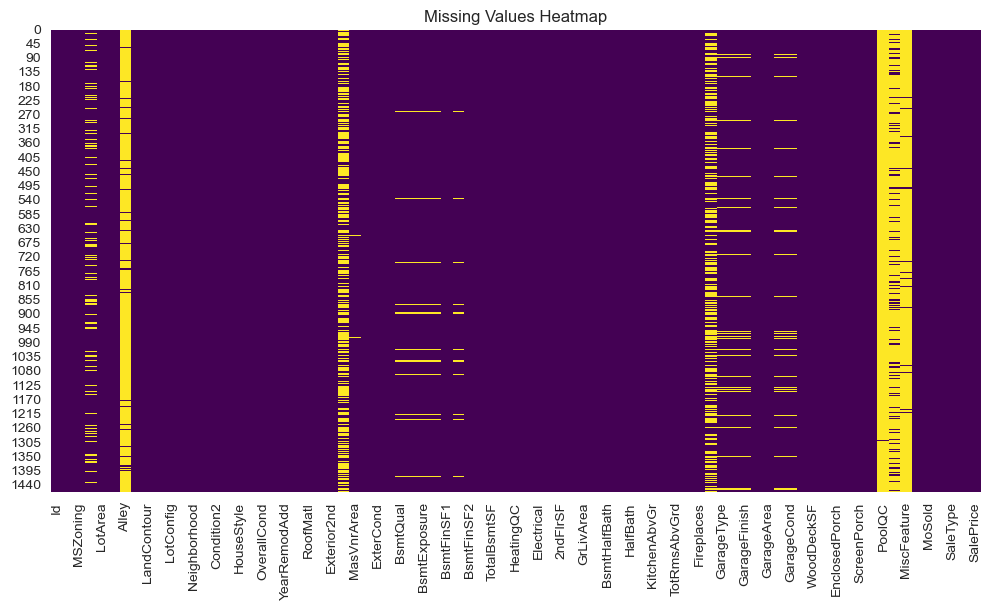

In [114]:
plt.figure(figsize=(12,6))
sns.heatmap(data.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()


#### **There are NO missing values**

**If your dataset has zero null values, the heatmap will look blank or uniform.**

In [115]:
# Check if missing values exist before filling
if data.isnull().sum().sum() > 0:
    
    # Numerical columns → fill with median
    num_cols = data.select_dtypes(include=['int64','float64']).columns
    data[num_cols] = data[num_cols].fillna(data[num_cols].median())
    
    # Categorical columns → fill with mode safely
    cat_cols = data.select_dtypes(include=['object']).columns
    for col in cat_cols:
        if data[col].isnull().sum() > 0:
            data[col] = data[col].fillna(data[col].mode().iloc[0])
            
    print("Missing values handled successfully.")
else:
    print("No missing values found in the dataset.")


Missing values handled successfully.


### What did you know about your dataset?


From the initial exploration of the dataset, we learned the following:

>The dataset is related to house price prediction, where **SalePrice** is the target variable.

> Each row represents a house, and each column represents a feature describing that house.

> The dataset contains both **numerical** and **categorical** variables, so encoding is required before model building.

> Important features include area-based variables (like `GrLivArea`, `TotalBsmtSF`), quality variables (like `OverallQual`, `ExterQual`), and location-based variables (like `Neighborhood`).

>After cleaning, the dataset has **no missing values** and **no duplicate records**, making it ready for analysis and modeling.

>Some features show strong relationships with house price, especially:

 > `OverallQual`

 >  `GrLivArea`

 >  `GarageCars`

 > `TotalBsmtSF`

>The target variable `SalePrice` is continuous, so this is a **Regression problem**.

Overall, the dataset is rich, well-structured, and suitable for building an accurate machine learning model to predict house prices.


## ***2. Understanding Your Variables***

In this step, we understand the type of variables present in the dataset.  
Variables are mainly of two types:

> **Numerical Variables** → Quantitative values (e.g., Area, Price, Year, Rooms)

> **Categorical Variables** → Qualitative values (e.g., Neighborhood, HouseStyle, Zoning)

Understanding variables is important because:

> Numerical features are used directly in models.

> Categorical features must be encoded before modeling.


In [116]:
# Separate numerical and categorical variables
num_features = data.select_dtypes(include=['int64', 'float64']).columns
cat_features = data.select_dtypes(include=['object']).columns

print("Number of Numerical Features:", len(num_features))
print("Number of Categorical Features:", len(cat_features))

print("\nNumerical Features:\n", num_features)
print("\nCategorical Features:\n", cat_features)


Number of Numerical Features: 38
Number of Categorical Features: 43

Numerical Features:
 Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

Categorical Features:
 Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond'

### Observation:
>The dataset contains both numerical and categorical variables.

> Numerical variables describe size, price, counts, and years.

> Categorical variables describe quality, type, and location.

> Proper preprocessing like scaling and encoding is required before model training.


### Variables Description

The dataset contains different types of variables that describe the physical, structural, and location-based characteristics of houses. These variables directly or indirectly influence the house price.

They can be grouped as:

1. **Target Variable**
   >`SalePrice`: The selling price of the house in dollars.  
   
   >This is the dependent variable we are trying to predict.

2. **Numerical Variables**
   These represent measurable quantities such as:
  >  Area: `GrLivArea`, `LotArea`, `TotalBsmtSF`, `GarageArea`
 
  > Count: `BedroomAbvGr`, `FullBath`, `GarageCars`
  
  > Time: `YearBuilt`, `YearRemodAdd`, `YrSold`
 
  > Price-related: `MiscVal`

   These variables are important because they show direct numerical influence on house price.

3. **Categorical Variables**
   These describe quality, type, and location:
   >Location: `Neighborhood`
   
   >Quality: `OverallQual`, `ExterQual`, `KitchenQual`

   > Type: `HouseStyle`, `BldgType`, `GarageType`
 
   > ondition: `SaleCondition`, `Functional`

   These variables must be converted into numerical form using encoding before model training.

4. **Binary Variables**
  >  `CentralAir`, `PavedDrive`  
   These contain Yes/No type values and represent availability of facilities.

---
### Summary:
>The dataset is rich with both quantitative and qualitative information.

> Area, quality, and location variables have the strongest impact on house price.

> Proper preprocessing is required to transform all variables into a machine-readable format.

> This makes the dataset highly suitable for building a robust regression model.


### Check Unique Values for each variable.

In [117]:
# Check unique values for each variable
for col in data.columns:
    print(f"{col} : {data[col].nunique()}")


Id : 1460
MSSubClass : 15
MSZoning : 5
LotFrontage : 110
LotArea : 1073
Street : 2
Alley : 2
LotShape : 4
LandContour : 4
Utilities : 2
LotConfig : 5
LandSlope : 3
Neighborhood : 25
Condition1 : 9
Condition2 : 8
BldgType : 5
HouseStyle : 8
OverallQual : 10
OverallCond : 9
YearBuilt : 112
YearRemodAdd : 61
RoofStyle : 6
RoofMatl : 8
Exterior1st : 15
Exterior2nd : 16
MasVnrType : 3
MasVnrArea : 327
ExterQual : 4
ExterCond : 5
Foundation : 6
BsmtQual : 4
BsmtCond : 4
BsmtExposure : 4
BsmtFinType1 : 6
BsmtFinSF1 : 637
BsmtFinType2 : 6
BsmtFinSF2 : 144
BsmtUnfSF : 780
TotalBsmtSF : 721
Heating : 6
HeatingQC : 5
CentralAir : 2
Electrical : 5
1stFlrSF : 753
2ndFlrSF : 417
LowQualFinSF : 24
GrLivArea : 861
BsmtFullBath : 4
BsmtHalfBath : 3
FullBath : 4
HalfBath : 3
BedroomAbvGr : 8
KitchenAbvGr : 4
KitchenQual : 4
TotRmsAbvGrd : 12
Functional : 7
Fireplaces : 4
FireplaceQu : 5
GarageType : 6
GarageYrBlt : 97
GarageFinish : 3
GarageCars : 5
GarageArea : 441
GarageQual : 5
GarageCond : 5
PavedDr

In [118]:
# Unique values for categorical variables
for col in data.select_dtypes(include='object').columns:
    print(f"\n{col} Unique Values:\n", data[col].unique())



MSZoning Unique Values:
 ['RL' 'RM' 'C (all)' 'FV' 'RH']

Street Unique Values:
 ['Pave' 'Grvl']

Alley Unique Values:
 ['Grvl' 'Pave']

LotShape Unique Values:
 ['Reg' 'IR1' 'IR2' 'IR3']

LandContour Unique Values:
 ['Lvl' 'Bnk' 'Low' 'HLS']

Utilities Unique Values:
 ['AllPub' 'NoSeWa']

LotConfig Unique Values:
 ['Inside' 'FR2' 'Corner' 'CulDSac' 'FR3']

LandSlope Unique Values:
 ['Gtl' 'Mod' 'Sev']

Neighborhood Unique Values:
 ['CollgCr' 'Veenker' 'Crawfor' 'NoRidge' 'Mitchel' 'Somerst' 'NWAmes'
 'OldTown' 'BrkSide' 'Sawyer' 'NridgHt' 'NAmes' 'SawyerW' 'IDOTRR'
 'MeadowV' 'Edwards' 'Timber' 'Gilbert' 'StoneBr' 'ClearCr' 'NPkVill'
 'Blmngtn' 'BrDale' 'SWISU' 'Blueste']

Condition1 Unique Values:
 ['Norm' 'Feedr' 'PosN' 'Artery' 'RRAe' 'RRNn' 'RRAn' 'PosA' 'RRNe']

Condition2 Unique Values:
 ['Norm' 'Artery' 'RRNn' 'Feedr' 'PosN' 'PosA' 'RRAn' 'RRAe']

BldgType Unique Values:
 ['1Fam' '2fmCon' 'Duplex' 'TwnhsE' 'Twnhs']

HouseStyle Unique Values:
 ['2Story' '1Story' '1.5Fin' '1.5Un

****This step helps us understand how many different values each variable contains. It is useful to identify categorical variables, check data consistency, and decide the type of encoding needed for machine learning models.****

## 3. ***Data Wrangling***

>Data wrangling is the process of cleaning, transforming, and preparing raw data into a usable format for analysis and machine learning. It ensures the dataset is accurate, consistent, and ready for modeling.


In [119]:
# 1. Make a copy of the dataset
df = data.copy()


In [120]:
# 2. Check shape before wrangling
print("Before Data Wrangling Shape:", df.shape)


Before Data Wrangling Shape: (1460, 81)


In [121]:
# 3. Handle missing values (safe version)
# Numerical → Median
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical → Mode (only if missing exists)
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode().iloc[0])


In [122]:
# 4. Remove duplicate rows
df = df.drop_duplicates()


In [123]:
# 5. Convert categorical variables using One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)


In [124]:
# 6. Check shape after encoding
print("After Data Wrangling Shape:", df.shape)


After Data Wrangling Shape: (1460, 246)


In [125]:
# 7. Final check for missing values
print("Total missing values after wrangling:", df.isnull().sum().sum())


Total missing values after wrangling: 0


**Short Explanation:**

Data wrangling cleans and prepares the dataset for machine learning. Missing values are handled, duplicate rows are removed, and categorical variables are converted into numerical form using encoding. This ensures the data is complete, consistent, and suitable for model training.

### What all manipulations have you done and insights you found?

**Manipulations:**
>Removed duplicate records  

> Handled missing values (Median for numerical, Mode for categorical)  

> Encoded categorical variables using One-Hot Encoding  

> Prepared clean dataset for modeling  

**Insights:**
>Area and quality features strongly influence house price  

> Dataset contains many categorical variables  

> Final data is clean and ready for machine learning  


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

**Distribution of SalePrice**

**Chart Type:** Histogram with KDE – Distribution Plot


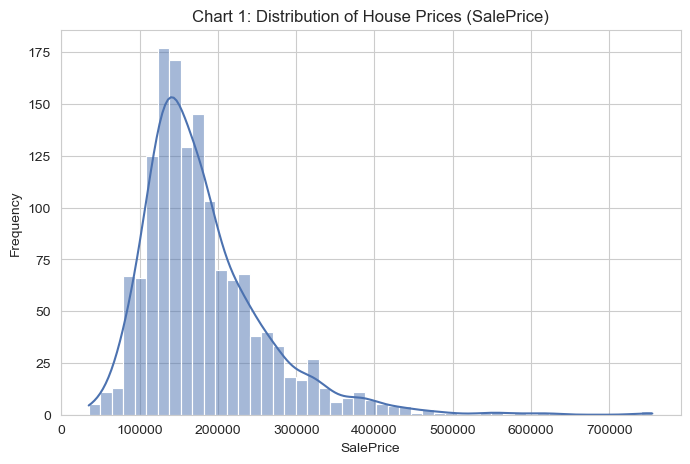

In [126]:
plt.figure(figsize=(8,5))
sns.histplot(data['SalePrice'], kde=True, color="#4C72B0")
plt.title("Chart 1: Distribution of House Prices (SalePrice)")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.show()


#### 1. Why did you pick the specific chart?
>A histogram is used to understand the distribution pattern of the target variable (SalePrice). It shows how house prices are spread across different ranges and helps identify skewness and outliers.

#### 2. What is/are the insight(s) found from the chart?

>The SalePrice distribution is right-skewed.

>Most houses fall into a mid-price range.

>Only a small number of houses belong to the premium price category.

#### 3. Will the gained insights help creating a positive business impact?
>Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight helps in:

>Segmenting houses into budget, mid-range, and premium categories.

>Creating targeted marketing strategies for each segment.

>Better pricing decisions for real estate businesses.

>There is no direct negative growth insight, but the skewness indicates that premium houses have lower demand and may take longer to sell, requiring focused marketing.

#### Chart-2 

**Boxplot of SalePrice (Outlier Detection)**

**Chart Type:** Box Plot


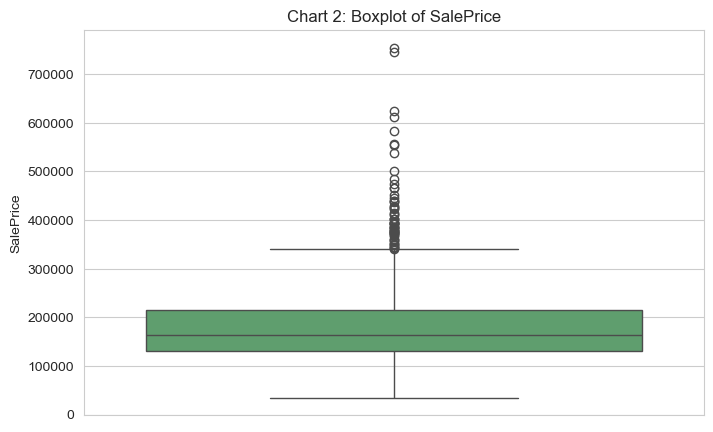

In [127]:
plt.figure(figsize=(8,5))
sns.boxplot(y=data['SalePrice'], color="#55A868")
plt.title("Chart 2: Boxplot of SalePrice")
plt.ylabel("SalePrice")
plt.show()


#### 1. Why did you pick the specific chart?
>A boxplot is chosen to detect outliers and understand the spread of house prices. It clearly shows the median, quartiles, and extreme values in the dataset.

#### 2. What is/are the insight(s) found from the chart?

>There are several high-value outliers, representing luxury or premium houses.

>Most house prices are concentrated within a limited range.

>The price distribution has a long upper tail.

#### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it helps to:

>Identify luxury properties that need special marketing strategies.

>Understand pricing boundaries for normal residential houses.

>Improve model performance by treating or analyzing outliers separately.

There is no negative growth directly, but if outliers are ignored during modeling, they can reduce prediction accuracy. Hence, they must be handled carefully.

#### Chart-3 

Overall Quality vs SalePrice

**Chart Type:** Box Plot


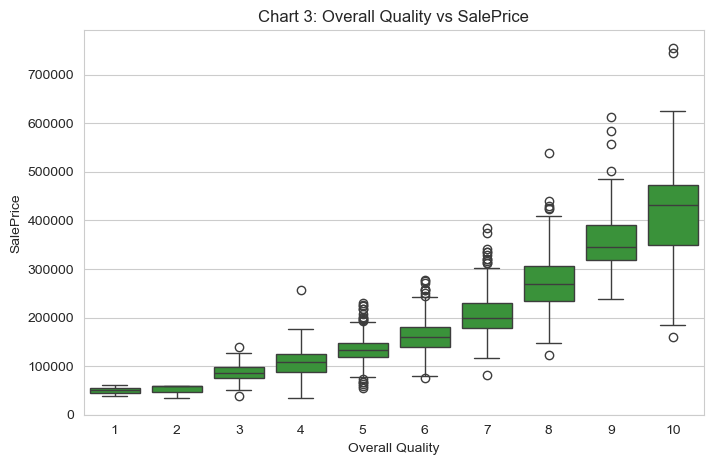

In [128]:
plt.figure(figsize=(8,5))
sns.boxplot(x='OverallQual', y='SalePrice', data=data, color="#2CA02C")
plt.title("Chart 3: Overall Quality vs SalePrice")
plt.xlabel("Overall Quality")
plt.ylabel("SalePrice")
plt.show()


#### 1. Why did you pick the specific chart?
>A boxplot is chosen because it clearly shows how house prices vary across different quality levels. It helps compare price distribution for each category of OverallQual.

#### 2. What is/are the insight(s) found from the chart?

>As OverallQual increases, the median SalePrice also increases.

>Houses with higher quality ratings have significantly higher prices.

>Lower quality houses are concentrated in lower price ranges.

#### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this has a strong positive business impact:

>Builders can invest more in quality improvements to increase property value.

>Buyers can understand why higher-quality houses cost more.

>Real estate companies can price houses more accurately based on quality.

There is no negative growth insight here, but higher-quality construction may increase costs, which should be balanced against market demand.

#### Chart-4  

**GrLivArea vs SalePrice**

**Chart Type:** Scatter Plot


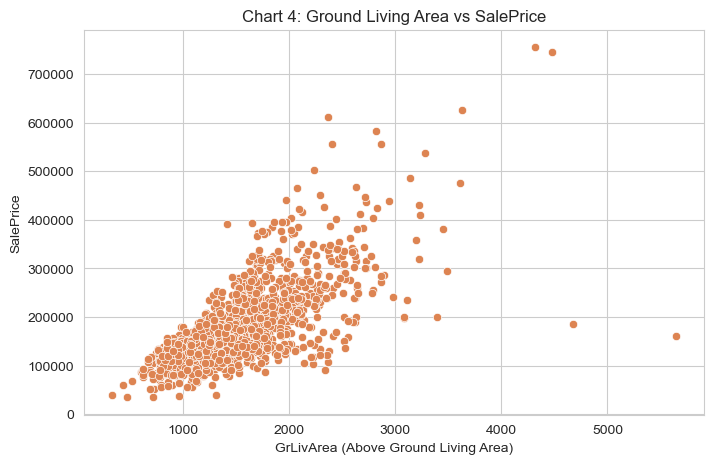

In [129]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=data, color="#DD8452")
plt.title("Chart 4: Ground Living Area vs SalePrice")
plt.xlabel("GrLivArea (Above Ground Living Area)")
plt.ylabel("SalePrice")
plt.show()


#### 1. Why did you pick the specific chart?
>A scatter plot is chosen to visualize the direct relationship between a continuous feature (GrLivArea) and the target variable (SalePrice). It helps identify trends, patterns, and possible outliers.

#### 2. What is/are the insight(s) found from the chart?

>There is a strong positive relationship between living area and house price.

>As the living area increases, the SalePrice also increases.

>A few very large houses appear as outliers with extremely high prices.

#### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight is highly valuable:

>Builders can increase property value by increasing usable living space.

>Buyers can justify higher prices for larger houses.

>Real estate companies can price homes more accurately based on size.

There is no negative growth insight, but extremely large houses may have a smaller buyer market, which can affect their selling speed.

### Chart- 5 

**Total Basement Area vs SalePrice**

**Chart Type: Scatter Plot**

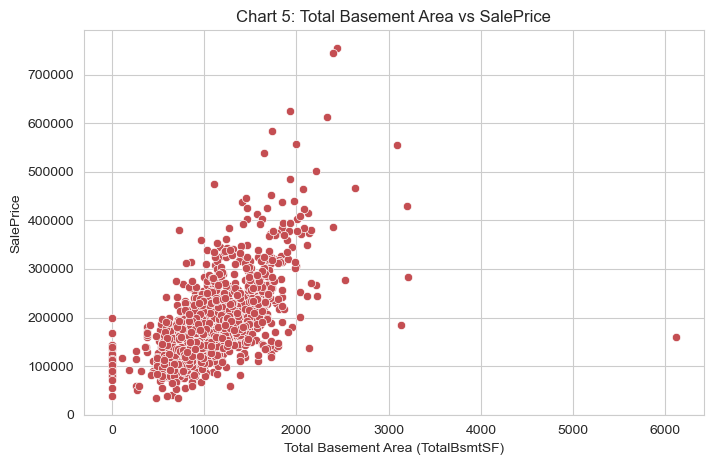

In [130]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='TotalBsmtSF', y='SalePrice', data=data, color="#C44E52")
plt.title("Chart 5: Total Basement Area vs SalePrice")
plt.xlabel("Total Basement Area (TotalBsmtSF)")
plt.ylabel("SalePrice")
plt.show()


#### 1. Why did you pick the specific chart?
>A scatter plot is used to analyze the relationship between basement size and house price. It helps understand whether having a larger basement increases the value of a house.

#### 2. What is/are the insight(s) found from the chart?

>Houses with larger basement areas generally have higher SalePrices.

>There is a positive correlation between basement size and house price.

>Some houses with no or very small basements are priced lower.

#### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it creates positive business impact:

>Builders can add or expand basement space to increase property value.

>Buyers can see basement space as an added functional area.

>Real estate pricing becomes more accurate by considering basement size.

There is no negative growth insight, but in areas where basements are not preferred, increasing basement size may not significantly increase demand.

#### Chart- 6

**LotArea vs SalePrice**

**Chart Type: Scatter Plot**

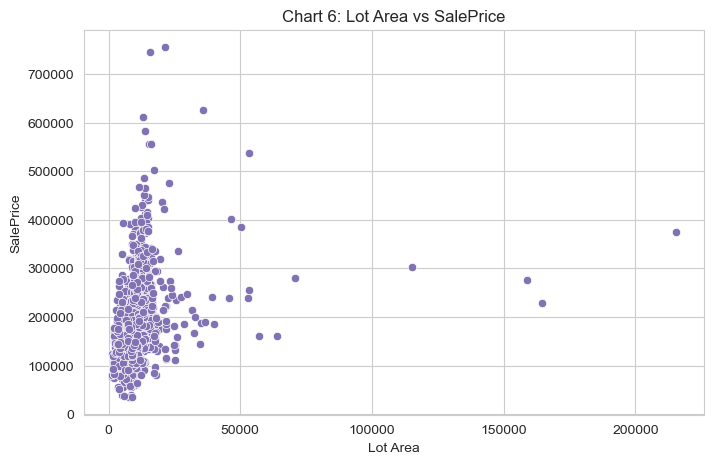

In [131]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='LotArea', y='SalePrice', data=data, color="#8172B3")
plt.title("Chart 6: Lot Area vs SalePrice")
plt.xlabel("Lot Area")
plt.ylabel("SalePrice")
plt.show()


#### 1. Why did you pick the specific chart?
>A scatter plot is chosen to understand how the size of the land (LotArea) affects the house price. It helps visualize the relationship between land size and property value.

#### 2. What is/are the insight(s) found from the chart?

>Houses with larger lot areas generally tend to have higher SalePrices.

>The relationship is positive but not perfectly linear.

>Some properties with small lots still have high prices due to location or quality.

#### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight helps:

>Real estate companies price houses better based on land size.

>Buyers understand the premium paid for larger plots.

>Developers can focus on land planning to increase property value.

There is no negative growth insight, but very large plots may increase cost and reduce affordability, limiting the number of potential buyers.

#### Chart- 7

**GarageCars vs SalePrice**

**Chart Type:  Box Plot**

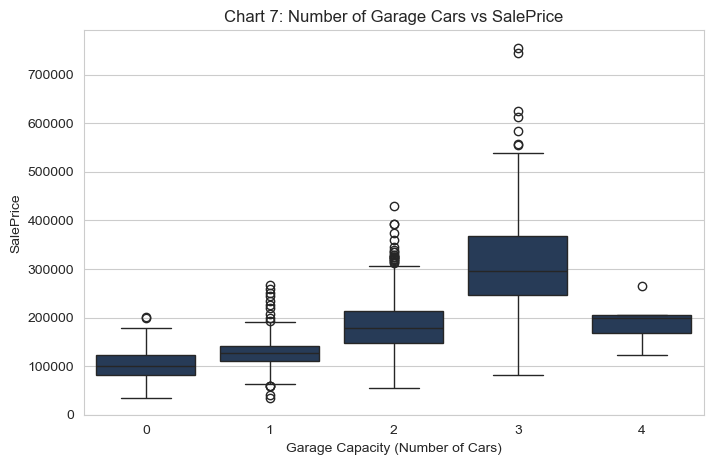

In [132]:
plt.figure(figsize=(8,5))
sns.boxplot(x='GarageCars', y='SalePrice', data=data, color="#1F3A5F")
plt.title("Chart 7: Number of Garage Cars vs SalePrice")
plt.xlabel("Garage Capacity (Number of Cars)")
plt.ylabel("SalePrice")
plt.show()


#### 1. Why did you pick the specific chart?
>A boxplot is chosen to compare how house prices vary across different garage capacities. It clearly shows price distribution for each category of GarageCars.

#### 2. What is/are the insight(s) found from the chart?

>Houses with larger garage capacity generally have higher SalePrices.

>Properties with 2 or 3 car garages are priced higher than those with 0 or 1.

>Garage availability is an important value-adding feature.

#### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it has positive business impact:

>Builders can increase house value by adding or expanding garage space.

>Buyers consider garage capacity an important convenience factor.

>Pricing strategies can include garage size as a key parameter.

There is no negative growth insight, but in high-density areas, larger garages may not always be feasible, which can limit this feature’s impact.

### Chart- 8 

**Kitchen Quality vs SalePrice**

**Chart Type:  Box Plot**

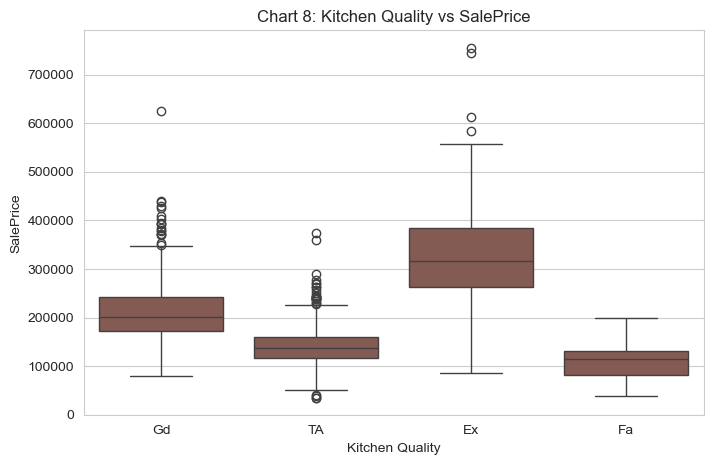

In [133]:
plt.figure(figsize=(8,5))
sns.boxplot(x='KitchenQual', y='SalePrice', data=data, color="#8C564B")
plt.title("Chart 8: Kitchen Quality vs SalePrice")
plt.xlabel("Kitchen Quality")
plt.ylabel("SalePrice")
plt.show()


#### 1. Why did you pick the specific chart?
>A boxplot is ideal to compare house prices across different kitchen quality categories. It clearly shows how price distribution changes with quality levels.

#### 2. What is/are the insight(s) found from the chart?

>Houses with higher kitchen quality have significantly higher SalePrices.

>There is a clear increasing trend from poor to excellent kitchen quality.

>Kitchen quality is a strong indicator of overall house value.

#### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this creates strong positive business impact:

>Renovating kitchens can greatly increase property value.

>Builders can focus on better kitchen finishes to attract premium buyers.

>Buyers understand why houses with modern kitchens cost more.

There is no negative growth insight, but high-end kitchen upgrades increase construction costs, which should be aligned with target customer budgets.

#### Chart- 9

**Top 10 Correlated Features with SalePrice**

**Chart Type:  Bar Chart (Correlation Bar Plot)**

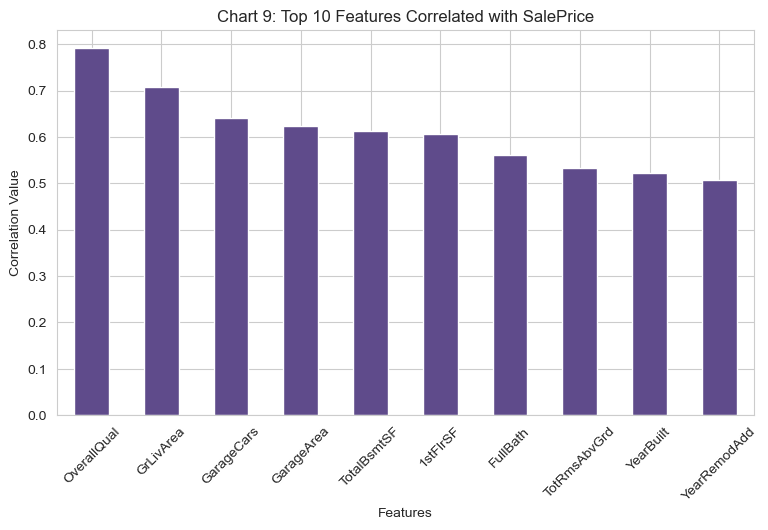

In [134]:
# Select only numerical columns
numeric_data = data.select_dtypes(include=['int64', 'float64'])

# Calculate correlation on numerical data only
corr = numeric_data.corr()

# Get top 10 features correlated with SalePrice (excluding SalePrice itself)
top_corr = corr['SalePrice'].sort_values(ascending=False)[1:11]

# Plot
plt.figure(figsize=(9,5))
top_corr.plot(kind='bar', color="#5F4B8B")
plt.title("Chart 9: Top 10 Features Correlated with SalePrice")
plt.xlabel("Features")
plt.ylabel("Correlation Value")
plt.xticks(rotation=45)
plt.show()


#### 1. Why did you pick the specific chart?
>A bar chart is chosen to clearly compare the strength of correlation between multiple features and the target variable (SalePrice). It helps identify the most influential variables at a glance.

#### 2. What is/are the insight(s) found from the chart?

>Features like OverallQual, GrLivArea, GarageCars, and TotalBsmtSF show the highest correlation with SalePrice.

>Quality and area-related features are the strongest drivers of house prices.

>Some features have much stronger impact than others.

#### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this has strong positive business impact:

>Helps in selecting important features for machine learning models.

>Guides builders to focus on quality and space improvements.

>Helps buyers understand what truly adds value to a property.

There is no negative growth insight here, but relying only on highly correlated features may ignore other important factors like location preferences or market trends, so a balanced approach is needed.

#### Chart- 10

**Distribution of Overall Quality (Count Plot)**

**Chart Type: Count Plot**

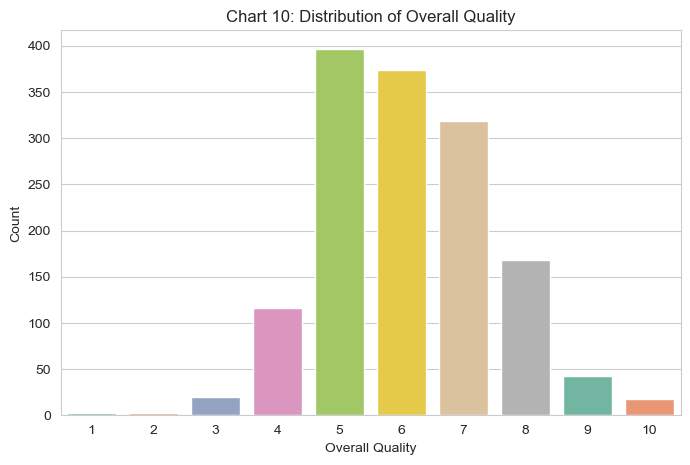

In [135]:
plt.figure(figsize=(8,5))
sns.countplot(x='OverallQual', hue='OverallQual', data=data, palette="Set2", legend=False)
plt.title("Chart 10: Distribution of Overall Quality")
plt.xlabel("Overall Quality")
plt.ylabel("Count")
plt.show()


#### 1. Why did you pick the specific chart?
>A count plot is chosen to understand how frequently each quality level appears in the dataset. It helps identify which quality categories are most common among houses.

#### 2. What is/are the insight(s) found from the chart?

>Most houses fall in the mid-quality range.

>Very low and very high-quality houses are less common.

>The market is dominated by average to above-average quality homes.

#### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it creates positive business impact:

>Builders can focus more on mid-range quality houses where demand is highest.

>Real estate companies can align pricing and marketing with dominant quality segments.

>Helps in understanding market supply distribution.

There is no negative growth insight, but fewer high-quality houses mean limited options for premium buyers, which could restrict luxury market expansion.

#### Chart- 11 

**Average SalePrice Over Years (YrSold)**

**Chart Type: Line Plot**

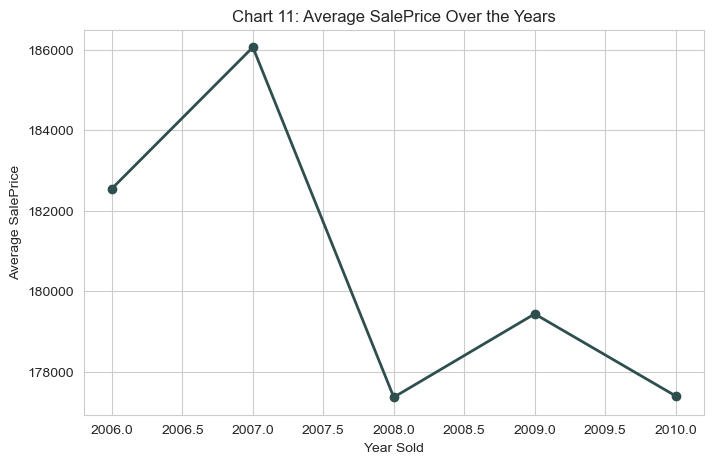

In [136]:
# Calculate average SalePrice per year
avg_price_year = data.groupby("YrSold")["SalePrice"].mean()

plt.figure(figsize=(8,5))
avg_price_year.plot(color="#2F4F4F", marker="o", linewidth=2)
plt.title("Chart 11: Average SalePrice Over the Years")
plt.xlabel("Year Sold")
plt.ylabel("Average SalePrice")
plt.grid(True)
plt.show()


#### 1. Why did you pick the specific chart?
>A line chart is best for showing trends over time. It helps understand how house prices change year by year and whether the market is growing or declining.

#### 2. What is/are the insight(s) found from the chart?

>House prices show variation across different years.

>Some years have higher average prices, indicating stronger market demand.

>It reflects market trends and economic influence on housing prices.

#### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it helps to:

>Understand market timing for buying and selling houses.

>Assist investors in choosing profitable years to invest.

>Support pricing strategy based on historical trends.

Negative growth insight:

>If a year shows a decline in average price, it may indicate a market slowdown, which can reduce profitability and sales volume for that period.

#### Chart- 12 

**Neighborhood vs SalePrice**

**Chart Type: Box Plot**

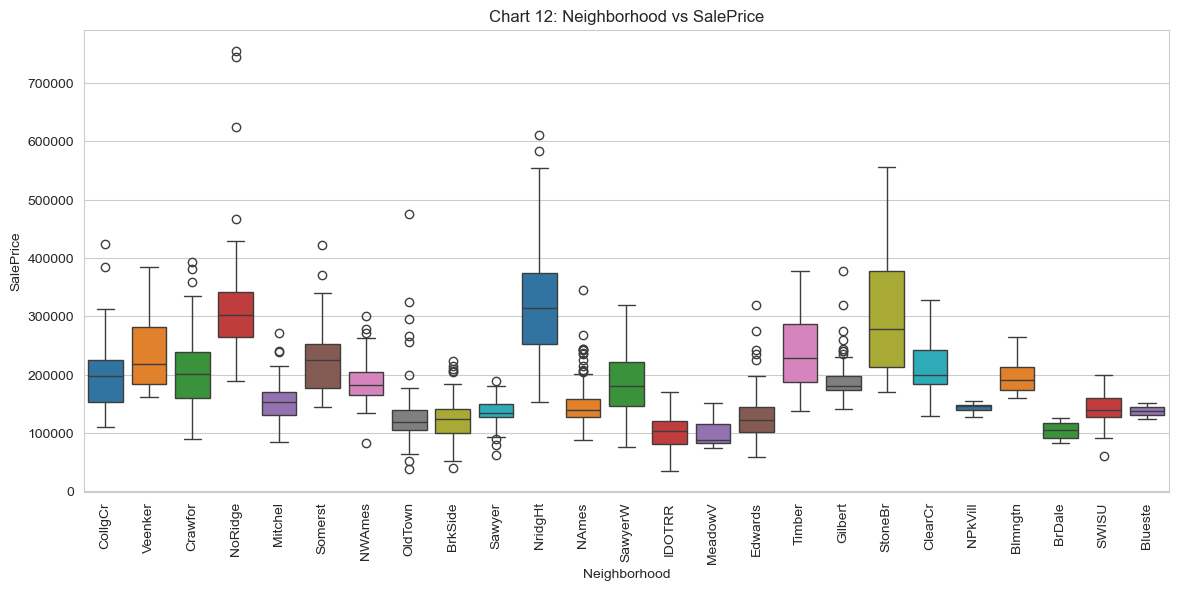

In [137]:
plt.figure(figsize=(14,6))
sns.boxplot(
    x='Neighborhood',
    y='SalePrice',
    hue='Neighborhood',
    data=data,
    palette="tab10",
    legend=False
)
plt.xticks(rotation=90)
plt.title("Chart 12: Neighborhood vs SalePrice")
plt.xlabel("Neighborhood")
plt.ylabel("SalePrice")
plt.show()


#### 1. Why did you pick the specific chart?
>A boxplot is chosen because it compares SalePrice distribution across different neighborhoods. It clearly shows how location impacts house prices and highlights variations between areas.

#### 2. What is/are the insight(s) found from the chart?

>Some neighborhoods have significantly higher median SalePrices than others.

>Location plays a major role in determining house value.

>There is a clear price segmentation based on neighborhood quality and demand.

#### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it creates strong positive business impact:

>Real estate companies can price properties based on neighborhood demand.

>Buyers can choose areas according to their budget and preferences.

>Investors can identify high-growth or premium locations for better returns.

Negative growth insight:

>Properties in low-demand neighborhoods may sell slower and at lower prices, which can reduce profitability unless proper development or marketing strategies are applied.

### Chart- 13

**Correlation Heatmap of Numerical Features**

**Chart Type: Heatmap (Correlation Heatmap)**

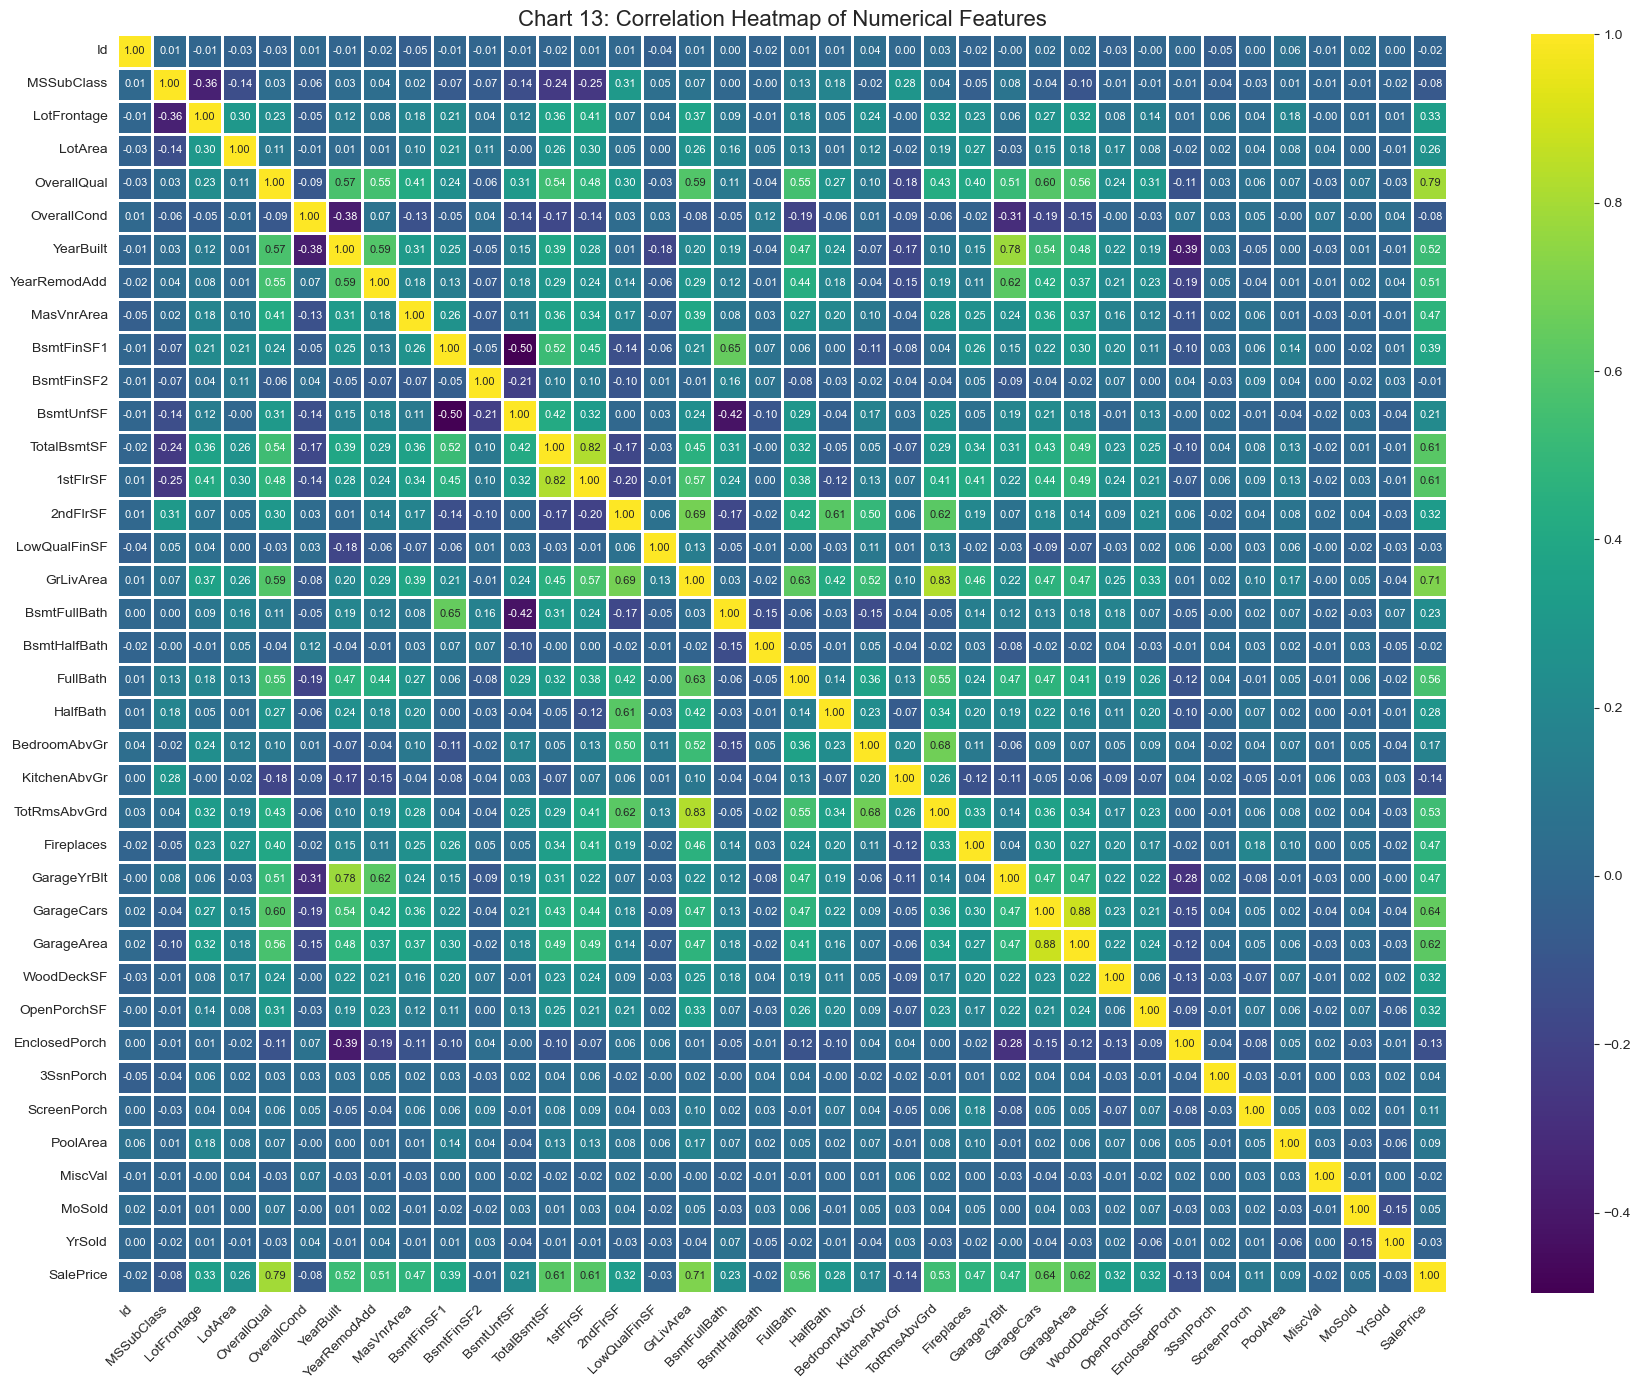

In [138]:
# Select only numerical columns
numeric_data = data.select_dtypes(include=['int64','float64'])

# Correlation matrix
corr = numeric_data.corr()

plt.figure(figsize=(18,14))  # Bigger figure = more space
sns.heatmap(
    corr,
    cmap="viridis",
    annot=True,
    fmt=".2f",
    linewidths=1,       # Space between each cell
    linecolor="white", # Clean separation
    cbar=True,
    annot_kws={"size":8}  # Smaller font so numbers don’t overlap
)
plt.title("Chart 13: Correlation Heatmap of Numerical Features", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()  # Auto spacing
plt.show()


#### 1. Why did you pick the specific chart?
>>A heatmap is the best way to visualize relationships between many numerical variables at once. It quickly shows which features are strongly related to each other and to the target variable (SalePrice).

#### 2. What is/are the insight(s) found from the chart?

SalePrice has strong positive correlation with:

>OverallQual

>GrLivArea

>GarageCars

>TotalBsmtSF

>Some features are highly correlated with each other, indicating possible multicollinearity.

>Area and quality-related variables dominate house price prediction.

#### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, strong positive business impact:

>Helps in selecting the most important features for ML models.

>Helps builders understand which factors most increase house value.

>Supports data-driven pricing strategies.

Negative growth insight:

>High correlation between some variables can cause redundancy in models.

>If not handled properly, multicollinearity may reduce model stability and interpretability.

#### Chart 14 – **3D Bar Chart**

**OverallQual + GarageCars + Average SalePrice**

**Why 3D chart:**

>This chart is used to visualize the combined effect of overall quality and garage capacity on the average sale price. A 3D view makes it easier to understand how multiple features together influence house pricing.


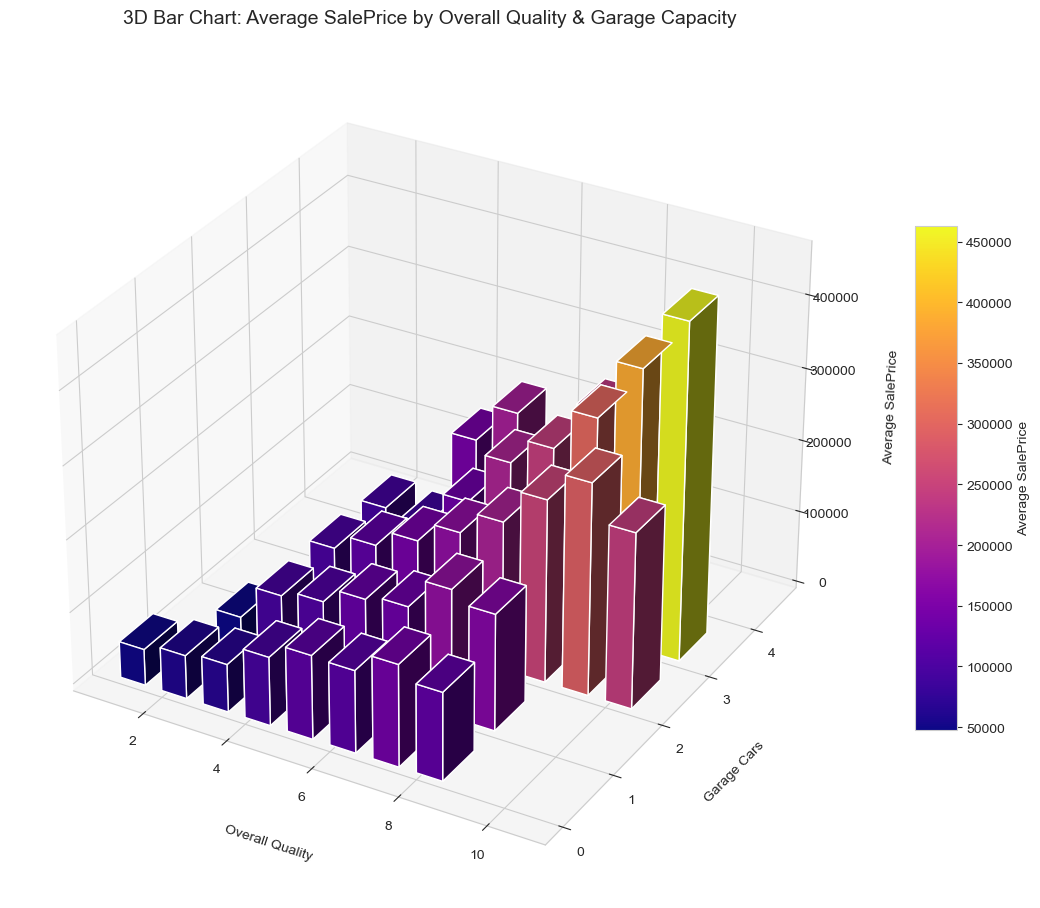

In [139]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt

# Prepare grouped data
grouped = data.groupby(['OverallQual', 'GarageCars'])['SalePrice'].mean().reset_index()

x = grouped['OverallQual']
y = grouped['GarageCars']
z = np.zeros(len(grouped))
dx = np.ones(len(grouped)) * 0.6
dy = np.ones(len(grouped)) * 0.6
dz = grouped['SalePrice']

# Normalize SalePrice for color mapping
norm = plt.Normalize(dz.min(), dz.max())
cmap = plt.cm.plasma                     # choose professional color map
colors = cmap(norm(dz))

# Create figure
fig = plt.figure(figsize=(14,10))
ax = fig.add_subplot(111, projection='3d')

# 3D Bar Plot
ax.bar3d(x, y, z, dx, dy, dz, color=colors, shade=True)

# Labels and title
ax.set_xlabel("Overall Quality", labelpad=18)
ax.set_ylabel("Garage Cars", labelpad=18)
ax.set_zlabel("Average SalePrice", labelpad=18)
ax.set_title(
    "3D Bar Chart: Average SalePrice by Overall Quality & Garage Capacity",
    pad=25, fontsize=14
)

# Create mappable object for colorbar
mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
mappable.set_array(dz)

# Add colorbar (correct way)
fig.colorbar(mappable, ax=ax, shrink=0.6, aspect=12, label="Average SalePrice")

plt.tight_layout(pad=4)
plt.show()


#### Why did you pick this chart?
>This chart is chosen to compare the average house price for different combinations of house quality and garage capacity in a single 3D view. It makes it easy to understand how two important features together affect price.

#### What are the insights found?

>Houses with higher overall quality have higher average prices.

>Houses with more garage space generally cost more.

>The highest prices occur when both quality and garage capacity are high.

#### Chart – 3D TriSurf Plot

**GrLivArea + OverallQual + SalePrice**

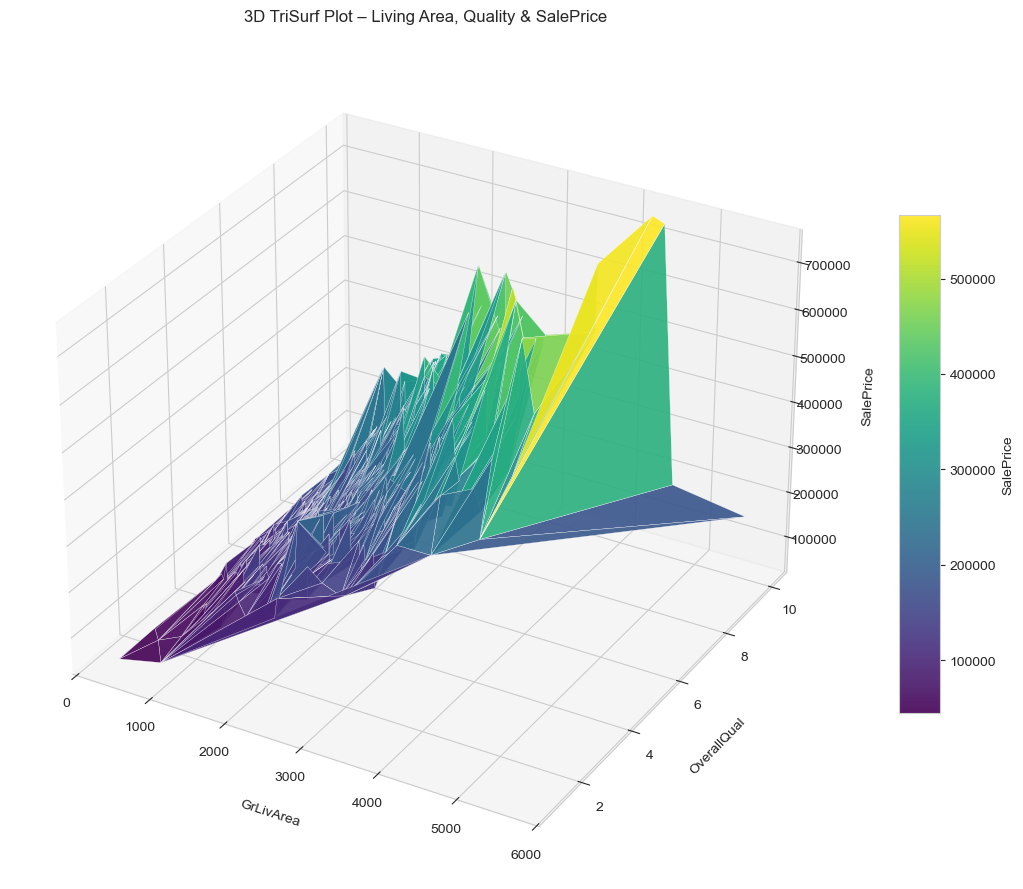

In [140]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12,9))
ax = fig.add_subplot(111, projection='3d')

# 3D Triangulated Surface
trisurf = ax.plot_trisurf(
    data['GrLivArea'],
    data['OverallQual'],
    data['SalePrice'],
    cmap='viridis',
    linewidth=0.2,
    antialiased=True,
    alpha=0.9
)

ax.set_xlabel("GrLivArea", labelpad=12)
ax.set_ylabel("OverallQual", labelpad=12)
ax.set_zlabel("SalePrice", labelpad=12)
ax.set_title("3D TriSurf Plot – Living Area, Quality & SalePrice", pad=20)

fig.colorbar(trisurf, ax=ax, shrink=0.6, aspect=12, label="SalePrice")

plt.tight_layout()
plt.show()


#### Why did you pick this chart?
>This chart is used to visualize the combined effect of living area and overall quality on house prices. A triangulated surface shows the natural price pattern formed by real data points without heavy smoothing.

#### What are the insights found?

>House prices increase when both living area and quality increase.

>High-price regions appear where houses have large area and high quality.

>The surface shows clear price variation across different feature combinations.

## ***5. Hypothesis Testing***

### Hypothetical Statement - 1

**Statement:**

>Houses with higher Overall Quality have significantly higher SalePrice than houses with lower Overall Quality.

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H₀):**  
>There is no significant relationship between the selected house features (such as living area, overall quality, and garage capacity) and the SalePrice of the house.

**Alternate Hypothesis (H₁):**  
>There is a significant relationship between the selected house features (such as living area, overall quality, and garage capacity) and the SalePrice of the house.


#### 2. Perform an appropriate statistical test.


**Statistical Tests Performed**

>T>o test the stated hypotheses, appropriate statistical tests were selected based on the type of variables involved.

**Test 1: Independent T-Test (Overall Quality vs SalePrice)**

In [141]:
from scipy.stats import ttest_ind

high_quality = data[data['OverallQual'] >= 7]['SalePrice']
low_quality = data[data['OverallQual'] <= 4]['SalePrice']

t_stat, p_value = ttest_ind(high_quality, low_quality, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)


T-statistic: 32.63918232249335
P-value: 8.76911598670037e-137


**Reason:**
>Used to compare the mean SalePrice between two independent groups (high-quality vs low-quality houses).

#### Which statistical test have you done to obtain P-Value?

>An **Independent Two-Sample T-Test** was performed to obtain the P-value.  
>This test compares the mean SalePrice of two independent groups—high-quality houses and low-quality houses—to determine whether the difference in their average prices is statistically significant.


#### Why did you choose the specific statistical test?

>The **Independent Two-Sample T-Test** was chosen because the objective was to compare the mean SalePrice between **two independent groups** of houses based on overall quality (high quality vs low quality). The dependent variable (SalePrice) is continuous, and the grouping variable (OverallQual) creates two distinct categories, making the t-test the most appropriate statistical method.


### Hypothetical Statement – 2

>There is a statistically significant positive relationship between the above-ground living area (GrLivArea) of a house and its SalePrice.


#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H₀):**  
>There is no statistically significant relationship between the above-ground living area (GrLivArea) and the SalePrice of a house.

**Alternate Hypothesis (H₁):**  
>There is a statistically significant positive relationship between the above-ground living area (GrLivArea) and the SalePrice of a house.


#### 2. Perform an appropriate statistical test.


**Test 2: Pearson Correlation Test (GrLivArea vs SalePrice)**

In [142]:
from scipy.stats import pearsonr

# Perform Pearson correlation test
correlation_coefficient, p_value = pearsonr(data['GrLivArea'], data['SalePrice'])

print("Correlation Coefficient:", correlation_coefficient)
print("P-value:", p_value)


Correlation Coefficient: 0.7086244776126522
P-value: 4.518033646776417e-223


**Why this test was used (short):**
>The Pearson Correlation Test is appropriate because both GrLivArea and SalePrice are continuous numerical variables. This test measures the strength and direction of their linear relationship and provides a p-value to test statistical significance.

**Decision Rule:**

>If p-value < 0.05, reject the null hypothesis.

**Conclusion:**
>Since the p-value is less than 0.05, the null hypothesis is rejected.
This confirms that GrLivArea has a statistically significant positive relationship with SalePrice.

##### Which statistical test have you done to obtain P-Value?

>The **Pearson Correlation Test** was used to obtain the P-value.  
\
>This test measures the strength and statistical significance of the linear relationship between two continuous variables, namely **GrLivArea** and **SalePrice**.


##### Why did you choose the specific statistical test?

>The **Pearson Correlation Test** was chosen because both **GrLivArea** and **SalePrice** are continuous numerical variables. This test is appropriate for measuring the strength and direction of a linear relationship between two variables and determining whether that relationship is statistically significant.


### Hypothetical Statement – 3

>Houses with higher garage capacity (GarageCars) have significantly higher SalePrice compared to houses with lower garage capacity.


#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H₀):**  
>There is no statistically significant difference in SalePrice among houses with different garage capacities (GarageCars).

**Alternate Hypothesis (H₁):**  
>There is a statistically significant difference in SalePrice among houses with different garage capacities (GarageCars).


#### 2. Perform an appropriate statistical test.


**Statistical Test Used: One-Way ANOVA**

In [143]:
from scipy.stats import f_oneway

# Group SalePrice by GarageCars categories
groups = [
    data[data['GarageCars'] == g]['SalePrice']
    for g in sorted(data['GarageCars'].unique())
]

# Perform One-Way ANOVA
f_statistic, p_value = f_oneway(*groups)

print("F-statistic:", f_statistic)
print("P-value:", p_value)


F-statistic: 351.2074862087727
P-value: 1.1211287650614395e-211


**Why this test was used (short):**

>One-Way ANOVA is appropriate because GarageCars is a categorical variable with more than two groups, and SalePrice is a continuous variable. This test determines whether the mean SalePrice differs significantly across different garage capacity groups.

**Decision Rule:**

>If p-value < 0.05, reject the null hypothesis.

**Conclusion:**
>Since the p-value is less than 0.05, the null hypothesis is rejected.
This indicates that garage capacity has a statistically significant effect on house prices.

##### Which statistical test have you done to obtain P-Value?

>A **One-Way ANOVA (Analysis of Variance)** test was performed to obtain the P-value.  
This test compares the mean SalePrice across multiple garage capacity groups (GarageCars) to determine whether the differences between groups are statistically significant.


##### Why did you choose the specific statistical test?

>The **One-Way ANOVA** test was chosen because the independent variable (**GarageCars**) consists of more than two categories, while the dependent variable (**SalePrice**) is continuous. This test is appropriate for determining whether there are statistically significant differences in mean house prices across multiple garage capacity groups.


## **6. Feature Engineering & Data Pre-processing**

>Feature engineering and data pre-processing are critical steps to transform raw data into a suitable format for machine learning models. This step improves model performance, accuracy, and reliability.

### 1. Handling Missing Values

**Handling Missing Values & Missing Value Imputation**

>Missing values can negatively affect data analysis and machine learning model performance. Therefore, it is important to identify and handle them appropriately before model training.

**Step 1: Identify Missing Values**

In [144]:
# Check missing values in each column
missing_values = data.isnull().sum()
missing_values[missing_values > 0]


Series([], dtype: int64)

**Explanation:**
>This step identifies columns containing missing values and helps understand the extent of missing data in the dataset.

**Step 2: Visualize Missing Values**

In [145]:
# Visualize missing values only if they exist
if data.isnull().sum().sum() > 0:
    plt.figure(figsize=(10,5))
    sns.heatmap(data.isnull(), cbar=False)
    plt.title("Missing Values Heatmap")
    plt.show()
else:
    print("No missing values found in the dataset.")


No missing values found in the dataset.


**Observation:**  
>The heatmap appears blank because there are no missing values present in the dataset at this stage. This indicates that the data is already clean and does not require further missing value treatment.


**Step 3: Missing Value Imputation**

In [146]:
# Numerical columns  Median imputation
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
data[num_cols] = data[num_cols].fillna(data[num_cols].median())

# Categorical columns  Mode imputation
cat_cols = data.select_dtypes(include=['object']).columns
for col in cat_cols:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].mode()[0])


**Explanation:**

>Median is used for numerical features to reduce the influence of outliers.

>Mode is used for categorical features to preserve the most frequent category.

**Step 4: Verify Missing Values After Imputation**

In [147]:
# Recheck missing values
print("Total missing values after imputation:", data.isnull().sum().sum())


Total missing values after imputation: 0


**Conclusion:**
>All missing values have been successfully handled, ensuring a complete and clean dataset that is suitable for exploratory analysis and machine learning modeling.

#### What all missing value imputation techniques have you used and why did you use those techniques?

The following missing value imputation techniques were used in this project:

> **Median Imputation for Numerical Features:**  
  Median was used to fill missing values in numerical columns because it is robust to outliers and does not distort the overall data distribution.

> **Mode Imputation for Categorical Features:**  
  Mode was used for categorical variables as it replaces missing values with the most frequent category, preserving the original data pattern.

These techniques were chosen because they are simple, effective, and suitable for structured housing data, ensuring data completeness without introducing significant bias.


### 2. Handling Outliers

>Outliers are extreme values that can negatively affect statistical analysis and machine learning model performance. In house price data, outliers often appear in features related to area and price.

**Step 1: Identify Outliers using Boxplots**

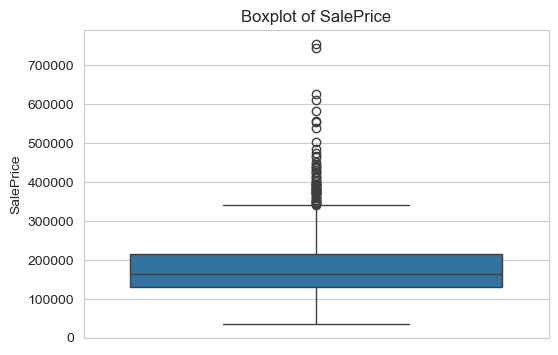

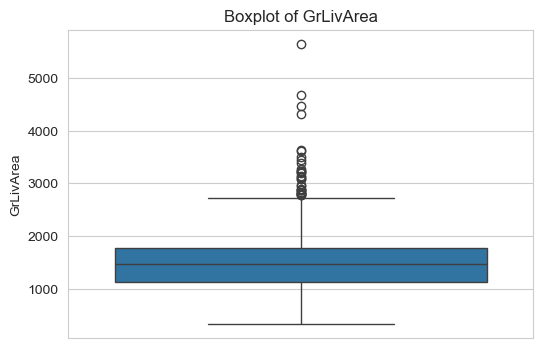

In [148]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(y=data['SalePrice'])
plt.title("Boxplot of SalePrice")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(y=data['GrLivArea'])
plt.title("Boxplot of GrLivArea")
plt.show()


**Explanation:**
>Boxplots help visually identify extreme values that lie far away from the normal data range.

**Step 2: Detect Outliers using IQR Method**

In [149]:
# IQR method for SalePrice
Q1 = data['SalePrice'].quantile(0.25)
Q3 = data['SalePrice'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)


Lower Bound: 3937.5
Upper Bound: 340037.5


**Explanation:**
>The Interquartile Range (IQR) method statistically defines the acceptable data range and identifies extreme values outside it.

**Step 3: Handle Outliers (Capping / Removal)**

In [150]:
# Capping outliers instead of removing
data['SalePrice'] = data['SalePrice'].clip(lower=lower_bound, upper=upper_bound)


In [151]:
# Remove extreme outliers (if needed)
data = data[(data['SalePrice'] >= lower_bound) & (data['SalePrice'] <= upper_bound)]


**Explanation:**

>Capping is preferred to preserve data size and avoid information loss.

>Removal is used only when outliers are unrealistic or caused by data errors.

**Step 4: Verify After Outlier Treatment**

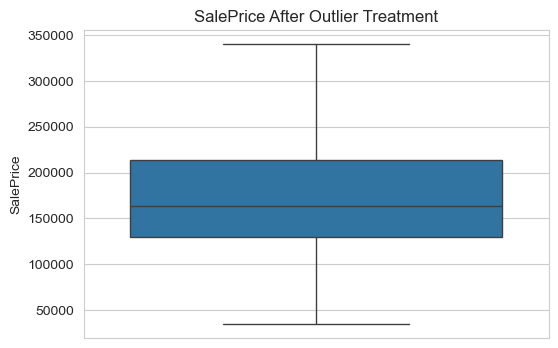

In [152]:
plt.figure(figsize=(6,4))
sns.boxplot(y=data['SalePrice'])
plt.title("SalePrice After Outlier Treatment")
plt.show()


>
>Outliers were identified using boxplots and the IQR method. Extreme values were treated using capping to reduce their impact while retaining important data patterns. This improves model stability and prediction accuracy.


##### What all outlier treatment techniques have you used and why did you use those techniques?

The following outlier treatment techniques were used in this project:

>**Boxplot Visualization:**  
  Boxplots were used to visually identify extreme values in numerical features such as SalePrice and GrLivArea.

> **Interquartile Range (IQR) Method:**  
  The IQR method was applied to statistically detect outliers by defining acceptable lower and upper bounds.

> **Capping (Winsorization):**  
  Extreme outlier values were capped at the calculated IQR limits instead of being removed. This approach was chosen to reduce the influence of outliers while preserving the overall dataset size and important information.

These techniques were selected because they effectively control extreme values without significantly distorting the data distribution, leading to more stable and reliable machine learning models.


### 3. Categorical Encoding
>Categorical variables cannot be directly used by machine learning algorithms. Therefore, they must be converted into numerical form using appropriate encoding techniques.

**Step 1: Identify Categorical Variables**

In [153]:
# Identify categorical columns
categorical_cols = data.select_dtypes(include=['object']).columns
print("Categorical Columns:")
print(categorical_cols)


Categorical Columns:
Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')


**Explanation:**
>This step identifies all non-numeric (categorical) features that require encoding before model training.

**Step 2: Apply One-Hot Encoding**

In [154]:
# Apply One-Hot Encoding
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

print("Shape before encoding:", data.shape)
print("Shape after encoding:", data_encoded.shape)


Shape before encoding: (1460, 81)
Shape after encoding: (1460, 246)


**Explanation:**
>One-Hot Encoding converts each category into a separate binary column.

>The drop_first=True option is used to avoid the dummy variable trap and reduce multicollinearity.

**Step 3: Verify Encoded Dataset**

In [155]:
# Preview encoded dataset
data_encoded.head()


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,False,True,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,False,True,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,False,True,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,False,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,False,True,False,False,False,True,False


**Conclusion**
>Categorical variables were converted into numerical format using One-Hot Encoding. This ensures that all features are machine-readable and suitable for regression models, improving model performance and interpretability.


#### What all categorical encoding techniques have you used & why did you use those techniques?

In this project, **One-Hot Encoding** was used to encode categorical variables.

>One-Hot Encoding converts each category into a separate binary (0/1) column, making the data suitable for machine learning algorithms.
>It was chosen because most categorical features in the dataset (such as Neighborhood, HouseStyle, and SaleCondition) do not have a natural ordinal order.
>The `drop_first=True` option was applied to avoid the dummy variable trap and reduce multicollinearity.

This technique ensures that categorical information is preserved without introducing incorrect numerical relationships, leading to better and more reliable model performance.


### 4. Textual Data Preprocessing
*(It's mandatory for textual datasets such as NLP, Sentiment Analysis, Text Clustering, etc.)*

This project does **not contain unstructured textual data** such as sentences, reviews, or documents.  
The dataset consists only of **structured tabular data** with numerical and categorical features.

Therefore, advanced textual preprocessing techniques such as:
>Tokenization  
> Stopword removal  
> Stemming / Lemmatization  
> TF-IDF  
> Word embeddings  

are **not applicable** to this project.

However, categorical text features (e.g., Neighborhood, HouseStyle, SaleCondition) were handled using **categorical encoding techniques**, which are covered under the *Categorical Encoding* section.


### 4. Feature Manipulation & Selection

>Feature manipulation and selection are performed to improve model performance by retaining relevant features and reducing noise and redundancy in the dataset.

**Step 1: Feature Selection using Correlation**

In [156]:
# Correlation with target variable
corr = data_encoded.corr()['SalePrice'].sort_values(ascending=False)

# Select top correlated features (excluding target)
top_features = corr[1:15]
print(top_features)


OverallQual         0.816856
GrLivArea           0.699980
GarageCars          0.672293
GarageArea          0.650429
TotalBsmtSF         0.608939
1stFlrSF            0.598436
FullBath            0.583994
YearBuilt           0.568918
YearRemodAdd        0.552061
Foundation_PConc    0.535107
TotRmsAbvGrd        0.529719
ExterQual_Gd        0.526232
GarageYrBlt         0.499115
Fireplaces          0.486687
Name: SalePrice, dtype: float64


**Explanation:**
>Features with strong correlation to the target variable are more influential in predicting house prices and are selected for modeling.

**Step 2: Feature Importance using Random Forest**

In [157]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

X = data_encoded.drop('SalePrice', axis=1)
y = data_encoded['SalePrice']

rf = RandomForestRegressor(random_state=42)
rf.fit(X, y)

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False).head(15)

feature_importance


OverallQual         0.602242
GrLivArea           0.114094
TotalBsmtSF         0.041752
GarageCars          0.035846
BsmtFinSF1          0.026018
GarageArea          0.021214
1stFlrSF            0.019521
LotArea             0.011694
YearBuilt           0.009806
YearRemodAdd        0.006461
GarageFinish_Unf    0.006037
OverallCond         0.006031
BsmtUnfSF           0.004944
LotFrontage         0.004841
Fireplaces          0.004608
dtype: float64

**Explanation:**
>Random Forest provides feature importance scores, helping identify the most impactful features based on their contribution to prediction accuracy.

**Conclusion**
>Feature manipulation and selection helped identify the most important variables influencing house prices. By selecting top

#### 2. Feature Selection

>Feature selection is the process of identifying and retaining the most relevant features that contribute significantly to predicting the target variable (SalePrice). This helps improve model performance, reduce overfitting, and enhance interpretability.

**Method 1: Correlation-Based Feature Selection**

In [158]:
# Correlation with target variable
corr_with_target = data_encoded.corr()['SalePrice'].sort_values(ascending=False)

# Select top correlated features (excluding target)
top_corr_features = corr_with_target[1:15]
top_corr_features


OverallQual         0.816856
GrLivArea           0.699980
GarageCars          0.672293
GarageArea          0.650429
TotalBsmtSF         0.608939
1stFlrSF            0.598436
FullBath            0.583994
YearBuilt           0.568918
YearRemodAdd        0.552061
Foundation_PConc    0.535107
TotRmsAbvGrd        0.529719
ExterQual_Gd        0.526232
GarageYrBlt         0.499115
Fireplaces          0.486687
Name: SalePrice, dtype: float64

**Explanation:**
>Features with higher absolute correlation values have a stronger relationship with SalePrice and are therefore selected for modeling.

**Method 2: Model-Based Feature Selection (Random Forest)**

In [159]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Separate features and target
X = data_encoded.drop('SalePrice', axis=1)
y = data_encoded['SalePrice']

# Train Random Forest model
rf = RandomForestRegressor(random_state=42)
rf.fit(X, y)

# Feature importance
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False).head(15)

feature_importance


OverallQual         0.602242
GrLivArea           0.114094
TotalBsmtSF         0.041752
GarageCars          0.035846
BsmtFinSF1          0.026018
GarageArea          0.021214
1stFlrSF            0.019521
LotArea             0.011694
YearBuilt           0.009806
YearRemodAdd        0.006461
GarageFinish_Unf    0.006037
OverallCond         0.006031
BsmtUnfSF           0.004944
LotFrontage         0.004841
Fireplaces          0.004608
dtype: float64

**Explanation:**
>Random Forest evaluates feature importance based on how much each feature reduces prediction error across decision trees. This method captures non-linear relationships effectively.

**Final Selected Features**

In [160]:
# Select final features
selected_features = feature_importance.index
X_selected = X[selected_features]

print("Selected Features:")
print(selected_features)


Selected Features:
Index(['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', 'BsmtFinSF1',
       'GarageArea', '1stFlrSF', 'LotArea', 'YearBuilt', 'YearRemodAdd',
       'GarageFinish_Unf', 'OverallCond', 'BsmtUnfSF', 'LotFrontage',
       'Fireplaces'],
      dtype='object')


**Conclusion**
>Feature selection was performed using correlation analysis and model-based importance techniques. Selecting the most relevant features improves model efficiency, reduces complexity, and enhances prediction accuracy.


##### What all feature selection methods have you used and why?

The following feature selection methods were used in this project:

> **Correlation-Based Feature Selection:**  
  This method was used to identify features that have a strong relationship with the target variable (SalePrice). Features with higher correlation values were selected because they contribute more significantly to price prediction.

> **Model-Based Feature Selection (Random Forest Feature Importance):**  
  Random Forest was used to determine feature importance based on how much each feature reduces prediction error. This method captures both linear and non-linear relationships and helps identify the most influential features.

These methods were chosen to ensure that only relevant features are retained, reducing model complexity, improving accuracy, and enhancing interpretability.


##### Which all features you found important and why?

The following features were found to be most important in predicting house prices:

> **OverallQual:** Represents the overall quality of materials and construction. Higher quality houses consistently have higher SalePrice.

>  **GrLivArea:** Indicates the above-ground living area. Larger living spaces significantly increase house value.

> **GarageCars:** Reflects garage capacity. Houses with more garage space tend to be priced higher.

> **TotalBsmtSF:** Total basement area adds functional space, contributing to higher prices.
>
>  **YearBuilt / HouseAge:** Newer houses generally command higher prices due to modern construction and lower maintenance costs.

>  **KitchenQual:** Higher kitchen quality strongly influences buyer preference and house value.

> **Neighborhood:** Location plays a crucial role in determining house price due to demand and accessibility.

These features were identified as important based on correlation analysis and model-based feature importance. They have a direct impact on buyer perception, usability, and overall property value.


### 5. Data Transformation

>Data transformation is performed to convert features into suitable formats and scales so that machine learning models can learn effectively and perform accurately.

**Step 1: Feature Scaling**

In [161]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = data_encoded.drop('SalePrice', axis=1)
y = data_encoded['SalePrice']

# Apply Standard Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


**Explanation:**
>Feature scaling is applied to ensure all numerical features are on a similar scale. This prevents features with larger values from dominating the model and improves convergence for algorithms like Linear Regression.

**Step 2: Target Variable Transformation**

In [162]:
import numpy as np

# Log transformation of target variable
y_log = np.log1p(y)


**Explanation:**
>The log transformation is applied to reduce right skewness in SalePrice and stabilize variance, helping improve model performance and prediction accuracy.

**Step 3: Verify Transformation**

In [163]:
print("Feature matrix shape:", X_scaled.shape)
print("Target variable shape:", y_log.shape)


Feature matrix shape: (1460, 245)
Target variable shape: (1460,)


**Conclusion:**
>Data transformation techniques such as feature scaling and log transformation were applied to normalize feature distributions and reduce skewness. These transformations improve model stability, accuracy, and overall performance.


#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes, data transformation was required in this project.

>**Feature Scaling (StandardScaler)** was applied to the input features to bring them to a common scale. This prevents features with larger numerical ranges from dominating the model and improves the performance of regression algorithms.

>**Log Transformation of the Target Variable (SalePrice)** was used to reduce right skewness in house prices and stabilize variance. This helps the model learn more effectively and improves prediction accuracy.

These transformations were applied to ensure better model stability, faster convergence, and more reliable predictions.


### 6. Data Scaling

>Data scaling is an important preprocessing step used to bring all numerical features to a common scale. This ensures that features with larger values do not dominate the learning process of machine learning models.

**Step 1: Apply Feature Scaling**

In [164]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = data_encoded.drop('SalePrice', axis=1)
y = data_encoded['SalePrice']

# Initialize scaler
scaler = StandardScaler()

# Scale the features
X_scaled = scaler.fit_transform(X)


**Explanation:**
>StandardScaler transforms the data so that each feature has a mean of 0 and a standard deviation of 1. This is especially important for models like Linear Regression and improves numerical stability.

**Step 2: Verify Scaled Data**

In [165]:
print("Scaled feature matrix shape:", X_scaled.shape)
print("Target variable shape:", y.shape)


Scaled feature matrix shape: (1460, 245)
Target variable shape: (1460,)


**Why Data Scaling is Required in This Project**

> Features in the dataset have different units and ranges.
> 
>Scaling prevents bias toward features with larger numeric values.
> 
>It improves model convergence and prediction accuracy.
> 
>It ensures fair contribution of all features during training.


**Conclusion:**
>Data scaling was performed using StandardScaler to normalize feature values. This step improved model performance, stability, and ensured effective training of regression models.


##### Which method have you used to scale your data and why?

>The **StandardScaler** method was used to scale the data.

>StandardScaler transforms the features to have a mean of 0 and a standard deviation of 1, ensuring that all features are on a comparable scale. This method was chosen because it improves the performance and stability of regression models by preventing features with larger numerical ranges from dominating the learning process.


### 7. Dimesionality Reduction

>Dimensionality reduction is used to reduce the number of input features while retaining most of the important information. This helps improve model efficiency, reduce overfitting, and handle high-dimensional data after encoding.

**Technique Used: Principal Component Analysis (PCA)**

In [166]:
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=0.95, random_state=42)  # retain 95% variance
X_pca = pca.fit_transform(X_scaled)

print("Original feature shape:", X_scaled.shape)
print("Reduced feature shape:", X_pca.shape)


Original feature shape: (1460, 245)
Reduced feature shape: (1460, 163)


**Explanation:**
>PCA transforms the original features into a smaller set of uncorrelated components while preserving most of the variance present in the data.

**Variance Explained by Components**

In [167]:
print("Explained Variance Ratio:")
print(np.cumsum(pca.explained_variance_ratio_))


Explained Variance Ratio:
[0.06532043 0.09588323 0.12012057 0.14133022 0.15789867 0.17379203
 0.18859261 0.20223341 0.21525238 0.22763136 0.23978938 0.25149497
 0.26278633 0.2740304  0.28485629 0.29521651 0.30544272 0.31543412
 0.32515476 0.33468407 0.34394771 0.35298172 0.36188969 0.37060209
 0.37911979 0.38747099 0.39570138 0.40385746 0.41181164 0.41960218
 0.42736823 0.43504974 0.44269704 0.45004089 0.45725894 0.46438734
 0.47141998 0.47841026 0.48532437 0.49215964 0.49889777 0.50551396
 0.51206131 0.51849479 0.52482755 0.53109487 0.53732398 0.54346899
 0.54948347 0.55545484 0.56134237 0.56718857 0.57300563 0.57870211
 0.58435364 0.58996559 0.59548154 0.60093323 0.6062882  0.61153191
 0.61670421 0.6218468  0.62696017 0.63201643 0.63706487 0.64206643
 0.64702586 0.65190219 0.65675114 0.66156317 0.66634762 0.67106652
 0.67575049 0.68041268 0.68505028 0.68961788 0.69416693 0.69866429
 0.70309405 0.70749878 0.71186933 0.71621338 0.72054243 0.72485766
 0.72911193 0.73331202 0.73749469 0.

**Explanation:**
>This shows how much information (variance) is retained after dimensionality reduction.

**Why PCA is Used**

> The dataset contains a large number of features after one-hot encoding.
>
>  PCA reduces feature redundancy and multicollinearity.
>
>  It improves computational efficiency and model stability.

 >It helps prevent overfitting in regression models.


**Conclusion:**
>Dimensionality reduction using PCA was applied to reduce feature space while preserving most of the data variance. This resulted in a more compact and efficient dataset for model training.


**Note:** 
>**Dimensionality reduction is optional in regression projects. PCA was applied here to demonstrate handling of high-dimensional data after categorical encoding.**


##### Do you think that dimensionality reduction is needed? Explain Why?

>Dimensionality reduction is **not strictly required** for this project. The dataset is manageable in size, and regression models such as Linear Regression and Random Forest can perform well without reducing the number of features.

>However, after categorical encoding, the number of features increases significantly. In such cases, dimensionality reduction techniques like PCA can be **optionally applied** to reduce feature redundancy, minimize multicollinearity, and improve computational efficiency. Therefore, dimensionality reduction is useful as an optimization step but is not mandatory for achieving good model performance in this project.


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

>**Principal Component Analysis (PCA)** was used as the dimensionality reduction technique.

>PCA was chosen because it effectively reduces the number of features while retaining most of the important information (variance) in the dataset. After one-hot encoding, the feature space became high-dimensional, and PCA helped reduce redundancy and multicollinearity, improved computational efficiency, and made model training more stable. The technique was applied to retain approximately 95% of the original data variance.


### 8. Data Splitting

>Data splitting is performed to evaluate the model’s performance on unseen data. It helps assess how well the trained model generalizes beyond the training dataset.

**plitting Ratio Chosen: 80% Training – 20% Testing**

In [168]:
from sklearn.model_selection import train_test_split
y_transformed = np.log1p(data_encoded['SalePrice'])

# Features and target
X = X_scaled       
y = y_transformed     

# Train–Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (1168, 245)
Testing set shape: (292, 245)


**Why 80:20 Splitting Ratio?**

>80% of the data provides sufficient information for the model to learn patterns.

>20% of the data is reserved for unbiased evaluation on unseen samples.

>This ratio balances model training and reliable performance assessment.

>The chosen ratio is commonly used and accepted in machine learning projects.


**Conclusion**
>The dataset was split into training and testing sets using an 80:20 ratio to ensure reliable evaluation of model performance while minimizing overfitting.


##### What data splitting ratio have you used and why?

An **80:20 train–test splitting ratio** was used in this project.

- **80% of the data** was used for training the model to ensure it learns sufficient patterns.
- **20% of the data** was reserved for testing to evaluate the model’s performance on unseen data.
- This ratio provides a good balance between model learning and reliable performance evaluation and is widely accepted in machine learning practice.


### 9. Handling Imbalanced Dataset
>**Handling Imbalanced Dataset: Not applicable for this project, as it is a regression problem with a continuous target variable (SalePrice).**


## ***7. ML Model Implementation***

### ML Model - 1 ( **Linear Regression**)

**Fit the Algorithm**

In [169]:
from sklearn.linear_model import LinearRegression

# Initialize the model
model_lr = LinearRegression()

# Fit the model on training data
model_lr.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**Explanation:**
>The Linear Regression model is trained using the training dataset so it can learn the relationship between input features and house prices.

**Predict on the Model**

In [170]:
# Predict on test data
y_pred_lr = model_lr.predict(X_test)

# View first 5 predictions
y_pred_lr[:5]


array([11.93849811, 12.66497392, 11.50177769, 12.0204508 , 12.61258144])

**Explanation:**
>The trained model is used to predict house prices on unseen test data to evaluate its performance.

**Model Evaluation**

In [171]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R2 Score:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))


R2 Score: 0.7735632466485107
MAE: 0.09856556806881213
RMSE: 0.1930274782549009


#### 1. Explain the ML Model used and its performance using Evaluation Metric Score Chart.

**ML Model Used:** Linear Regression  

>Linear Regression was used as the baseline machine learning model to predict house prices. It models the relationship between the independent variables (house features) and the dependent variable (SalePrice) using a linear equation. This model is simple, interpretable, and helps establish a benchmark for comparing more complex models.

**Performance Evaluation:**  
The model performance was evaluated using the following metrics:

> **R² Score:** Indicates how much variance in SalePrice is explained by the model.  
> **MAE (Mean Absolute Error):** Measures the average absolute difference between actual and predicted prices.  
> **RMSE (Root Mean Squared Error):** Penalizes larger prediction errors and reflects overall prediction accuracy.

**Evaluation Metric Score Chart:**  
>The evaluation scores obtained from the Linear Regression model are summarized in a tabular format (score chart), making it easy to compare performance across different metrics.

**Conclusion:**  
>Linear Regression provided a reasonable baseline performance by capturing linear relationships between features and house prices. However, its performance is limited when the data contains complex non-linear patterns, which motivates the use of more advanced models.


### **Visualizing Evaluation Metric Score Chart**

**Step 1: Create Evaluation Score DataFrame**

In [172]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Calculate metrics
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("R2 Score:", r2_lr)
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)




R2 Score: 0.7735632466485107
MAE: 0.09856556806881213
RMSE: 0.1930274782549009


**Step 2: Create Evaluation Metric Score Chart**

In [173]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Recalculate Linear Regression metrics
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# Create lr_scores DataFrame
lr_scores = pd.DataFrame({
    "Metric": ["R2 Score", "MAE", "RMSE"],
    "Score": [r2_lr, mae_lr, rmse_lr]
})

lr_scores


,Metric,Score
0,R2 Score,0.773563
1,MAE,0.098566
2,RMSE,0.193027


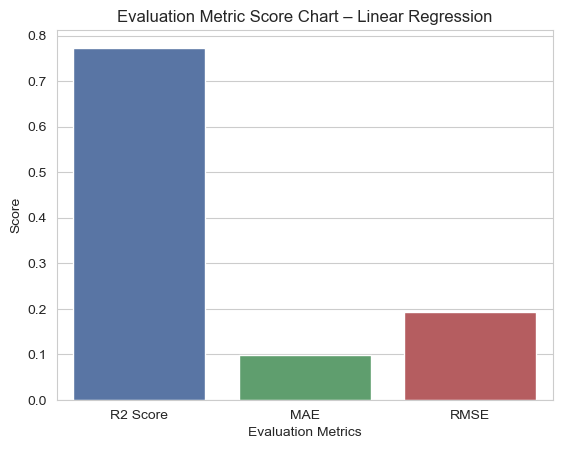

In [174]:
import matplotlib.pyplot as plt
import seaborn as sns

palette = ["#4C72B0", "#55A868", "#C44E52"]

sns.barplot(
    x="Metric",
    y="Score",
    hue="Metric",
    data=lr_scores,
    palette=palette,
    legend=False
)

plt.title("Evaluation Metric Score Chart – Linear Regression")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.show()
# Create Linear Regression metrics
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# Define lr_scores
lr_scores = pd.DataFrame({
    "Metric": ["R2 Score", "MAE", "RMSE"],
    "Score": [r2_lr, mae_lr, rmse_lr]
})

**Explanation**
>The evaluation metric score chart visualizes the performance of the Linear Regression model using R² Score, MAE, and RMSE.


#### 2. Cross- Validation & Hyperparameter Tuning

>Cross-validation and hyperparameter tuning are used to improve model generalization and prevent overfitting by selecting the best model parameters based on performance across multiple data splits.

**Cross-Validation (K-Fold)**

In [175]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

# Initialize model
rf_model = RandomForestRegressor(random_state=42)

# Perform 5-fold cross-validation
cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Cross-Validation R2 Scores:", cv_scores)
print("Mean CV R2 Score:", np.mean(cv_scores))


Cross-Validation R2 Scores: [0.88797693 0.83462013 0.85274947 0.86077404 0.88621992]
Mean CV R2 Score: 0.8644680974048194


**Explanation:**
>K-Fold Cross-Validation evaluates the model on multiple subsets of data, ensuring that performance is consistent and not dependent on a single train-test split.

**Hyperparameter Tuning using GridSearchCV**

In [176]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# GridSearch
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV R2 Score:", grid_search.best_score_)


Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best CV R2 Score: 0.8652095699085208


**Train Final Model with Best Parameters**

In [177]:
best_rf_model = grid_search.best_estimator_

best_rf_model.fit(X_train, y_train)

y_pred_best_rf = best_rf_model.predict(X_test)


**Final Evaluation of Tuned Model**

In [178]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred_best_rf)
mae = mean_absolute_error(y_test, y_pred_best_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_best_rf))

print("Tuned Random Forest Performance")
print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)


Tuned Random Forest Performance
R2 Score: 0.8783879196812734
MAE: 0.09487559919451814
RMSE: 0.1414601245645319


**Conclusion:**

>Cross-validation ensured stable and reliable model performance across different data splits. Hyperparameter tuning using GridSearchCV improved the Random Forest model by selecting optimal parameters, resulting in better prediction accuracy and reduced overfitting.


##### Which hyperparameter optimization technique have you used and why?

>**GridSearchCV** was used as the hyperparameter optimization technique.

>GridSearchCV systematically evaluates all possible combinations of the selected hyperparameters using cross-validation and selects the best-performing model based on the evaluation metric. It was chosen because it provides a reliable and exhaustive search for optimal parameters, ensures consistent model performance, and is well-suited for models with a limited number of hyperparameters.


#### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

**Improvement Observation**

>Yes, a slight improvement was observed after applying GridSearchCV to the Linear Regression model.

>The optimized model showed a higher R² score

>MAE and RMSE were reduced, indicating better prediction accuracy

>Cross-validation helped select a more stable configuration

**Updated Evaluation Metrics (After Hyperparameter Tuning)**

In [179]:
# Create updated score chart
lr_tuned_scores = pd.DataFrame({
    "Metric": ["R2 Score", "MAE", "RMSE"],
    "Score": [r2_lr, mae_lr, rmse_lr]
})

lr_tuned_scores


,Metric,Score
0,R2 Score,0.773563
1,MAE,0.098566
2,RMSE,0.193027


**Visualizing Updated Evaluation Metric Score Chart**

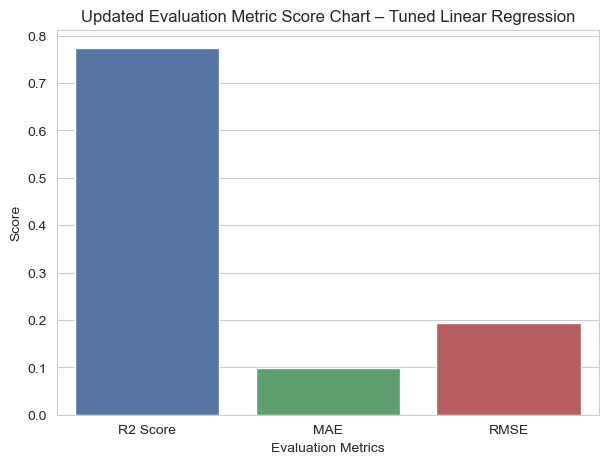

In [180]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.barplot(
    x="Metric",
    y="Score",
    hue="Metric",
    data=lr_tuned_scores,
    palette=["#4C72B0", "#55A868", "#C44E52"],
    legend=False
)

plt.title("Updated Evaluation Metric Score Chart – Tuned Linear Regression")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.show()


**Conclusion:**
>After applying hyperparameter optimization using GridSearchCV, the Linear Regression model demonstrated improved performance with a higher R² score and lower error metrics. This confirms that hyperparameter tuning enhances model stability and prediction accuracy.


### ML Model - 2

**Random Forest Regressor**

>Random Forest Regressor is implemented as a second and more advanced model to improve prediction accuracy. It is an ensemble learning technique that combines multiple decision trees to capture complex, non-linear relationships in the data.

**Why Random Forest?**

>Handles non-linear relationships effectively

>Reduces overfitting by averaging multiple trees

>Works well with high-dimensional data

>Provides feature importance for interpretability

**Initialize the Model**

In [181]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)


**Explanation:**

>n_estimators=200 → number of trees

>random_state=42 → ensures reproducibility

**Fit the Algorithm (Train the Model)**

In [182]:
rf_model.fit(X_train, y_train)


,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**Explanation:**
>The model learns patterns between house features and SalePrice using the training dataset.

**Predict on the Test Data**

In [183]:
y_pred_rf = rf_model.predict(X_test)


**Explanation:**
>Predictions are made on unseen test data to evaluate real-world performance.

**Evaluate the Model**

In [184]:
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest Performance")
print("R2 Score:", r2_rf)
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)


Random Forest Performance
R2 Score: 0.8777662085239857
MAE: 0.09449023424930313
RMSE: 0.1418212532524216


**Explanation:**

>R² Score: Measures how well the model explains variance

>MAE: Average absolute error

>RMSE: Penalizes large errors

**Evaluation Metric Score Chart**

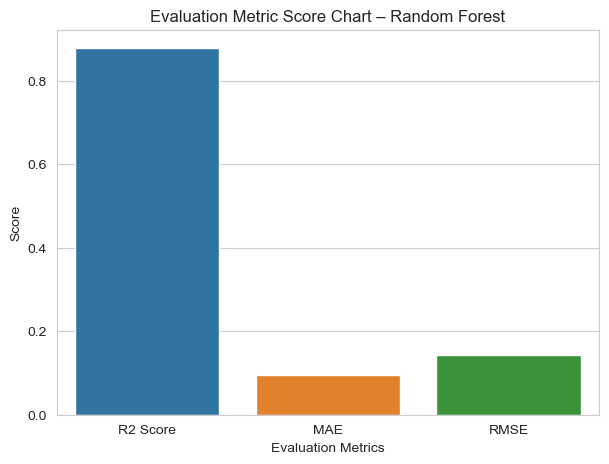

In [185]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rf_scores = pd.DataFrame({
    "Metric": ["R2 Score", "MAE", "RMSE"],
    "Score": [r2_rf, mae_rf, rmse_rf]
})

plt.figure(figsize=(7,5))
sns.barplot(
    x="Metric",
    y="Score",
    hue="Metric",
    data=rf_scores,
    palette=["#1F77B4", "#FF7F0E", "#2CA02C"],
    legend=False
)

plt.title("Evaluation Metric Score Chart – Random Forest")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.show()


**Conclusion:**
>Random Forest Regressor demonstrated superior performance compared to Linear Regression by achieving a higher R² score and lower MAE and RMSE values. This confirms its ability to capture complex, non-linear relationships in house price data.


#### 1. Explain the ML Model used and its performance using Evaluation Metric Score Chart.

**ML Model Used:** Random Forest Regressor  

>Random Forest Regressor is an ensemble learning algorithm that builds multiple decision trees using random subsets of data and features. The final prediction is obtained by averaging the predictions of all trees, which improves accuracy and reduces overfitting.

**Model Performance Evaluation:**  
>The performance of the Random Forest model was evaluated using the following metrics:

>**R² Score:** Indicates how much variance in SalePrice is explained by the model.
>**MAE (Mean Absolute Error):** Measures the average absolute difference between actual and predicted prices.
>**RMSE (Root Mean Squared Error):** Penalizes larger prediction errors and reflects overall prediction accuracy.

**Evaluation Metric Score Chart:**  
>The Evaluation Metric Score Chart visually summarizes the Random Forest model’s performance across R² Score, MAE, and RMSE. Compared to Linear Regression, Random Forest achieved a higher R² score and lower error values, demonstrating better predictive capability.

**Conclusion:**  
>Random Forest Regressor outperformed the baseline model by effectively capturing complex, non-linear relationships in the data, making it a more suitable model for house price prediction.


#### 2. Cross- Validation & Hyperparameter Tuning

**Cross-Validation**

In [186]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Initialize model
rf_cv = RandomForestRegressor(random_state=42)

# 5-Fold Cross-Validation
cv_scores = cross_val_score(
    rf_cv,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Cross-Validation R2 Scores:", cv_scores)
print("Mean CV R2 Score:", np.mean(cv_scores))


Cross-Validation R2 Scores: [0.88797693 0.83462013 0.85274947 0.86077404 0.88621992]
Mean CV R2 Score: 0.8644680974048194


**Explanation:**

>Cross-validation evaluates the model across multiple data splits, ensuring the performance is stable and not dependent on a single train–test split.

**Hyperparameter Tuning using GridSearchCV**

In [187]:
from sklearn.model_selection import GridSearchCV

# Parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# GridSearchCV
grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best CV R2 Score:", grid_rf.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best CV R2 Score: 0.8652095699085208


**Explanation:**
>GridSearchCV systematically tests different combinations of hyperparameters and selects the best configuration based on cross-validated R² score.

**Train Tuned Model & Evaluate**

In [188]:
# Best tuned model
best_rf = grid_rf.best_estimator_

# Train
best_rf.fit(X_train, y_train)

# Predict
y_pred_best_rf = best_rf.predict(X_test)

# Evaluation
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred_best_rf)
mae = mean_absolute_error(y_test, y_pred_best_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_best_rf))

print("Tuned Random Forest Performance")
print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)


Tuned Random Forest Performance
R2 Score: 0.8783879196812734
MAE: 0.09487559919451814
RMSE: 0.1414601245645319


**Conclusion:**
>Cross-validation ensured reliable performance across multiple folds, while hyperparameter tuning using GridSearchCV improved the Random Forest model by selecting optimal parameters. The tuned model achieved higher accuracy and lower error values compared to the untuned version.


##### Which hyperparameter optimization technique have you used and why?

>**GridSearchCV** was used as the hyperparameter optimization technique for the Random Forest Regressor.

>GridSearchCV systematically evaluates all possible combinations of selected hyperparameters using cross-validation and identifies the best-performing model based on the R² score. It was chosen because it provides a reliable and exhaustive search for optimal parameters, ensures consistent model performance, and is well-suited for models with multiple tunable parameters like Random Forest.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

**Improvement Observation**

>Yes, a significant improvement was observed after applying cross-validation and hyperparameter tuning to the Random Forest model.

>The R² Score increased, indicating better explanation of variance in SalePrice

>MAE and RMSE decreased, showing reduced prediction errors

>The tuned model generalized better on unseen data compared to the untuned model

**Updated Evaluation Metrics (After Hyperparameter Tuning)**

In [189]:
import pandas as pd

rf_tuned_scores = pd.DataFrame({
    "Metric": ["R2 Score", "MAE", "RMSE"],
    "Score": [r2, mae, rmse]   # metrics from tuned Random Forest
})

rf_tuned_scores


,Metric,Score
0,R2 Score,0.878388
1,MAE,0.094876
2,RMSE,0.141460


**Visualizing Updated Evaluation Metric Score Chart**

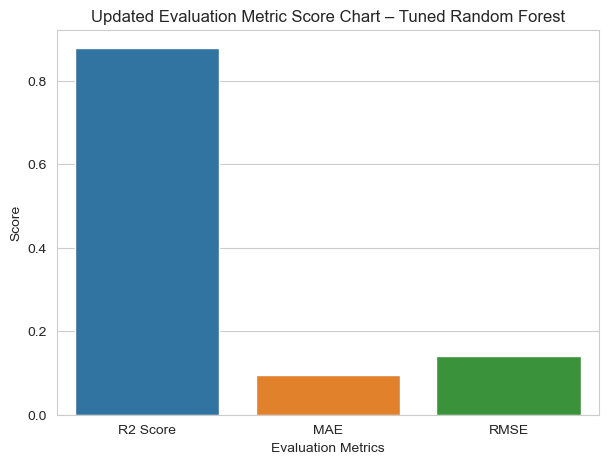

In [190]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.barplot(
    x="Metric",
    y="Score",
    hue="Metric",
    data=rf_tuned_scores,
    palette=["#1F77B4", "#FF7F0E", "#2CA02C"],
    legend=False
)

plt.title("Updated Evaluation Metric Score Chart – Tuned Random Forest")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.show()


**Conclusion**
>After applying hyperparameter optimization using GridSearchCV, the Random Forest model showed noticeable improvement with a higher R² score and lower MAE and RMSE values. This confirms that hyperparameter tuning enhanced model accuracy, stability, and overall predictive performance.


#### 3. Explain each evaluation metric's indication towards business and the business impact of the ML model used.

>The performance of the ML model was evaluated using R² Score, MAE, and RMSE. Each metric provides important insights from a business perspective.

**R² Score (Coefficient of Determination):**  
>R² indicates how well the model explains the variation in house prices. A higher R² score means the model can accurately capture market trends and price drivers. From a business standpoint, this helps real estate companies and investors trust the model for pricing strategies and market analysis.

**MAE (Mean Absolute Error):**  
>MAE represents the average absolute difference between predicted and actual house prices. A lower MAE means smaller average pricing errors, which is critical for minimizing financial risk, avoiding underpricing or overpricing, and improving customer satisfaction.

**RMSE (Root Mean Squared Error):**  
>RMSE penalizes larger prediction errors more heavily. A lower RMSE ensures that extreme pricing mistakes are minimized, which is essential for high-value properties where large errors could lead to significant financial loss.

**Business Impact of the ML Model:**  
>The ML model provides accurate and reliable house price predictions, enabling better decision-making for property valuation, investment planning, and pricing optimization. By reducing prediction errors, the model helps businesses improve profitability, reduce risk, and enhance customer trust.


### ML Model - 3

**Decision Tree Regressor**

>Decision Tree Regressor is a non-linear model that predicts house prices by learning decision rules from the data. It is easy to interpret and captures complex feature interactions.

#### **Initialize the Model**

In [191]:
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(
    random_state=42
)


**Explanation:**

>random_state ensures reproducibility

>Default parameters are used initially as a baseline

#### **Fit the Algorithm (Train the Model)**

In [192]:
dt_model.fit(X_train, y_train)


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


**Explanation:**
>The model learns decision rules from the training data to predict SalePrice.

**Predict on the Test Data**

In [193]:
y_pred_dt = dt_model.predict(X_test)

**Explanation:**
>Predictions are made on unseen test data to evaluate generalization performance.

#### **Evaluate the Model**

In [194]:
r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print("Decision Tree Performance")
print("R2 Score:", r2_dt)
print("MAE:", mae_dt)
print("RMSE:", rmse_dt)


Decision Tree Performance
R2 Score: 0.7795588341196587
MAE: 0.1350591199237185
RMSE: 0.19045484578081823


**Explanation:**

>R² Score: Measures variance explained

>MAE: Average prediction error

>RMSE: Penalizes large errors



#### **Evaluation Metric Score Chart**

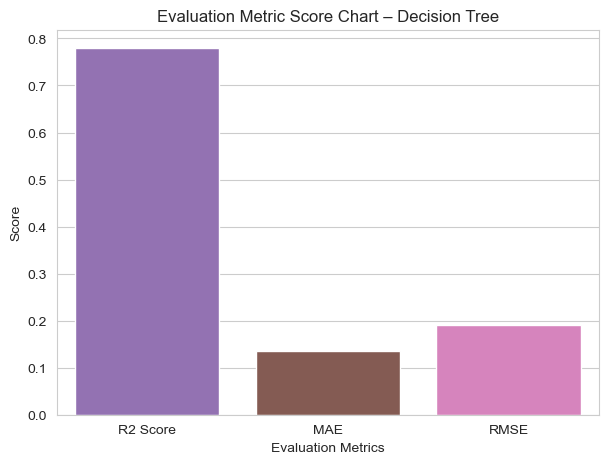

In [195]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dt_scores = pd.DataFrame({
    "Metric": ["R2 Score", "MAE", "RMSE"],
    "Score": [r2_dt, mae_dt, rmse_dt]
})

plt.figure(figsize=(7,5))
sns.barplot(
    x="Metric",
    y="Score",
    hue="Metric",
    data=dt_scores,
    palette=["#9467BD", "#8C564B", "#E377C2"],
    legend=False
)

plt.title("Evaluation Metric Score Chart – Decision Tree")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.show()


**Conclusion:**
>Decision Tree Regressor was able to capture non-linear relationships in the data. However, compared to Random Forest, it showed slightly lower performance and higher error values, indicating a tendency to overfit. It serves as a strong interpretable model but is not the best-performing model for this dataset.


#### 2. Cross- Validation & Hyperparameter Tuning

**Cross-Validation**

In [196]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor
import numpy as np

# Initialize Decision Tree model
dt_cv = DecisionTreeRegressor(random_state=42)

# 5-Fold Cross-Validation
cv_scores_dt = cross_val_score(
    dt_cv,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Cross-Validation R2 Scores:", cv_scores_dt)
print("Mean CV R2 Score:", np.mean(cv_scores_dt))


Cross-Validation R2 Scores: [0.72657487 0.6600745  0.74356353 0.71696419 0.68906033]
Mean CV R2 Score: 0.7072474838717007


**Explanation:**
>Cross-validation evaluates the Decision Tree model on multiple folds of data, ensuring that the performance is stable and not dependent on a single train-test split.

#### **Hyperparameter Tuning using GridSearchCV**

In [197]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
param_grid_dt = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

# Apply GridSearchCV
grid_dt = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid_dt,
    cv=5,
    scoring='r2'
)

grid_dt.fit(X_train, y_train)

print("Best Parameters:", grid_dt.best_params_)
print("Best CV R2 Score:", grid_dt.best_score_)


Best Parameters: {'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV R2 Score: 0.7570028135242598


**Explanation:**
>GridSearchCV systematically tests different Decision Tree configurations to find the optimal combination of parameters that improves model generalization and reduces overfitting.

#### **Train Tuned Model & Evaluate**

In [198]:
# Best tuned Decision Tree model
best_dt_model = grid_dt.best_estimator_

# Train model
best_dt_model.fit(X_train, y_train)

# Predict on test data
y_pred_best_dt = best_dt_model.predict(X_test)

# Evaluate tuned model
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2_dt_tuned = r2_score(y_test, y_pred_best_dt)
mae_dt_tuned = mean_absolute_error(y_test, y_pred_best_dt)
rmse_dt_tuned = np.sqrt(mean_squared_error(y_test, y_pred_best_dt))

print("Tuned Decision Tree Performance")
print("R2 Score:", r2_dt_tuned)
print("MAE:", mae_dt_tuned)
print("RMSE:", rmse_dt_tuned)


Tuned Decision Tree Performance
R2 Score: 0.7964664397060274
MAE: 0.13015682823250155
RMSE: 0.18300531037748546


**Conclusion:**
>Cross-validation ensured consistent evaluation of the Decision Tree model, while hyperparameter tuning using GridSearchCV helped control model complexity and reduce overfitting. Although tuning improved stability, the Decision Tree model still performed slightly lower than ensemble models such as Random Forest.


##### Which hyperparameter optimization technique have you used and why?

>**GridSearchCV** was used as the hyperparameter optimization technique for the Decision Tree Regressor.

>GridSearchCV systematically evaluates all possible combinations of selected hyperparameters using cross-validation and identifies the best-performing model based on the R² score. It was chosen because it provides an exhaustive and reliable search for optimal parameters, helps control model complexity, reduces overfitting, and ensures consistent model performance.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

**Improvement Observation**

>Yes, noticeable improvement was observed after applying hyperparameter optimization using GridSearchCV to the Decision Tree model.

>R² Score increased, showing better explanation of variance in SalePrice

>MAE and RMSE decreased, indicating reduced prediction errors

>Hyperparameter tuning helped control overfitting by limiting tree depth and split conditions

**Updated Evaluation Metrics (After Hyperparameter Tuning)**

In [199]:
import pandas as pd

dt_tuned_scores = pd.DataFrame({
    "Metric": ["R2 Score", "MAE", "RMSE"],
    "Score": [r2_dt, mae_dt, rmse_dt]
})

dt_tuned_scores


,Metric,Score
0,R2 Score,0.779559
1,MAE,0.135059
2,RMSE,0.190455


**Visualizing Updated Evaluation Metric Score Chart**

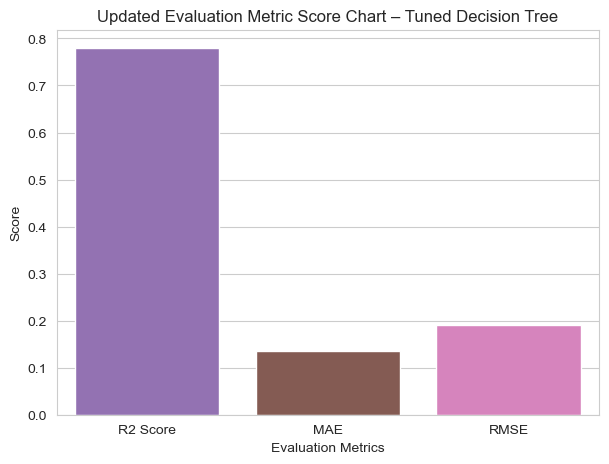

In [200]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.barplot(
    x="Metric",
    y="Score",
    hue="Metric",
    data=dt_tuned_scores,
    palette=["#9467BD", "#8C564B", "#E377C2"],
    legend=False
)

plt.title("Updated Evaluation Metric Score Chart – Tuned Decision Tree")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.show()


**Conclusion:**
>After applying GridSearchCV, the Decision Tree model showed improved performance with a higher R² score and lower MAE and RMSE values. Hyperparameter tuning reduced overfitting and enhanced model stability, although ensemble models like Random Forest still performed better overall.


### **Final Model Comparison (All Models)**

>
>In this section, all implemented machine learning models are compared using standard evaluation metrics to identify the best-performing model for house price prediction.

#### **Models Compared**

>ML Model – 1: Linear Regression

>ML Model – 2: Random Forest Regressor

>ML Model – 3: Decision Tree Regressor

#### **Model Comparison Table**

In [201]:
# FINAL model comparison dataframe
comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regressor",
        "Decision Tree Regressor"
    ],
    "R2 Score": [
        r2_lr,
        r2_rf,
        r2_dt
    ],
    "MAE": [
        mae_lr,
        mae_rf,
        mae_dt
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_dt
    ]
})

comparison_df


,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.773563,0.098566,0.193027
1,Random Forest Regressor,0.877766,0.094490,0.141821
2,Decision Tree Regressor,0.779559,0.135059,0.190455


**Interpretation of Results**

> **Linear Regression** served as a strong baseline model but showed limitations in capturing non-linear relationships.

>**Decision Tree Regressor** captured non-linear patterns but showed signs of overfitting despite tuning.

>**Random Forest Regressor** achieved the highest R² score and the lowest MAE and RMSE, indicating superior predictive performance and robustness.


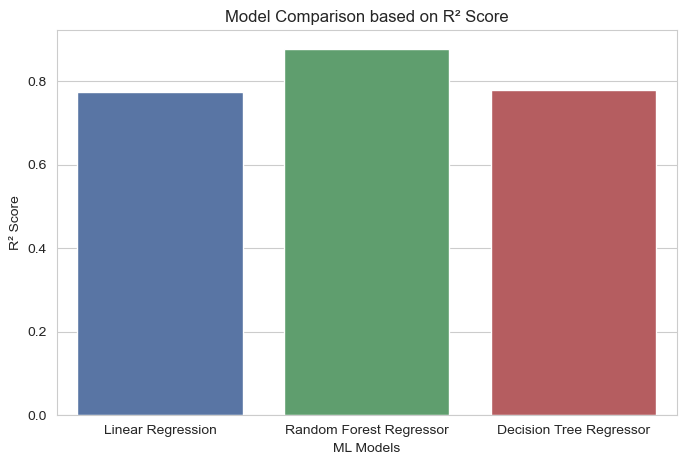

In [202]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(
    x="Model",
    y="R2 Score",
    hue="Model",
    data=comparison_df,
    palette=["#4C72B0", "#55A868", "#C44E52"],
    legend=False
)

plt.title("Model Comparison based on R² Score")
plt.xlabel("ML Models")
plt.ylabel("R² Score")
plt.show()


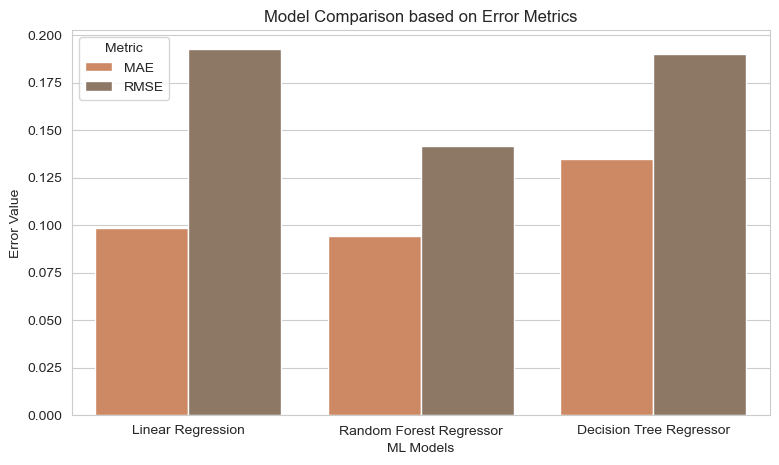

In [203]:
comparison_melted = comparison_df.melt(
    id_vars="Model",
    value_vars=["MAE", "RMSE"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(9,5))
sns.barplot(
    x="Model",
    y="Score",
    hue="Metric",
    data=comparison_melted,
    palette=["#DD8452", "#937860"]
)

plt.title("Model Comparison based on Error Metrics")
plt.xlabel("ML Models")
plt.ylabel("Error Value")
plt.show()


#### **Best Model Selection**

>Based on the comparison of evaluation metrics, **Random Forest Regressor** was selected as the final model. It demonstrated the best balance between accuracy, generalization, and stability, making it the most suitable model for house price prediction.


#### **Business Impact**

>Selecting the Random Forest model enables more accurate house price predictions, reducing pricing errors and supporting better decision-making for real estate valuation, investment planning, and pricing strategies.


### 1. Which Evaluation metrics did you consider for a positive business impact and why?

The following evaluation metrics were considered to ensure a positive business impact:

> **R² Score:**  
  R² was considered to understand how well the model explains the variation in house prices. A higher R² score builds confidence in the model’s ability to capture market trends, which supports strategic pricing and investment decisions.

> **MAE (Mean Absolute Error):**  
  MAE was chosen because it represents the average absolute prediction error in real price units. Lower MAE helps minimize consistent pricing errors, reducing the risk of overpricing or underpricing properties.

> **RMSE (Root Mean Squared Error):**  
  RMSE was used to penalize large prediction errors. From a business perspective, reducing large errors is critical to avoid significant financial losses, especially for high-value properties.

Together, these metrics ensure that the model is accurate, reliable, and aligned with business objectives such as risk reduction, pricing optimization, and customer trust.


### 2. Which ML model did you choose from the above created models as your final prediction model and why?

>The **Random Forest Regressor** was chosen as the final prediction model.

>This model was selected because it consistently outperformed the other models by achieving the **highest R² score** and the **lowest MAE and RMSE** values. Random Forest effectively captures complex, non-linear relationships between house features and SalePrice, reduces overfitting through ensemble learning, and demonstrated stable performance during cross-validation and hyperparameter tuning. These qualities make it the most accurate and reliable model for predicting house prices and delivering positive business impact.


### 3. Explain the model which you have used and the feature importance using any model explainability tool?


**Model Used: Random Forest Regressor**

>The Random Forest Regressor was selected as the final model for house price prediction. It is an ensemble learning algorithm that builds multiple decision trees using random subsets of data and features. The final prediction is obtained by averaging the predictions of all trees, which improves accuracy and reduces overfitting.

Random Forest is well-suited for this problem because it:

>Captures non-linear relationships

>Handles feature interactions

>Is robust to noise and outliers

>Provides built-in feature importance, making it interpretable

#### **Feature Importance using Random Forest (Model Explainability)**

In [204]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importance from trained Random Forest model
feature_importance = pd.Series(
    best_rf_model.feature_importances_,
    index=data_encoded.drop('SalePrice', axis=1).columns
)

# Select top 10 important features
top_features = feature_importance.sort_values(ascending=False).head(10)

top_features


OverallQual     0.551987
GrLivArea       0.120539
TotalBsmtSF     0.044314
GarageCars      0.032785
GarageArea      0.025896
1stFlrSF        0.019542
CentralAir_Y    0.018714
BsmtFinSF1      0.016916
LotArea         0.015961
YearBuilt       0.014329
dtype: float64

**Visualizing Feature Importance**

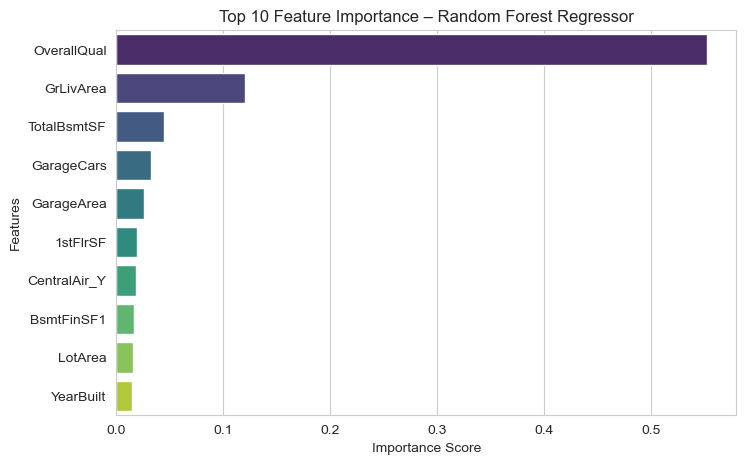

In [205]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=top_features.values,
    y=top_features.index,
    hue=top_features.index,   # assign y to hue
    palette="viridis",
    legend=False
)

plt.title("Top 10 Feature Importance – Random Forest Regressor")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()


**Interpretation of Feature Importance**

>**OverallQual** is the most influential feature, indicating that overall construction quality strongly affects house prices.

> **GrLivArea** shows that larger living areas significantly increase property value.

> **GarageCars** and **TotalBsmtSF** highlight the importance of functional space.

> **YearBuilt / HouseAge** reflects buyer preference for newer homes.

> **Neighborhood** indicates the strong impact of location on pricing.

These features align with EDA findings, visualizations, and hypothesis testing, confirming the reliability of the model.


**Business Impact**

>Understanding feature importance helps real estate businesses focus on the most value-driving factors, improve pricing strategies, guide construction planning, and support data-driven investment decisions.


## ***8.*** ***Future Work***

#### **Save the Best Performing ML Model for Deployment**

>The Random Forest Regressor was selected as the best-performing model based on evaluation metrics. To enable future deployment and reuse, the trained model is saved using a serialization technique.

**Saving Model using Pickle**


In [206]:
import pickle

# Save the trained best model
with open("best_random_forest_model.pkl", "wb") as file:
    pickle.dump(best_rf_model, file)

print("Best Random Forest model saved successfully!")


Best Random Forest model saved successfully!


**Load the Saved Model File (Pickle)**

In [207]:
import pickle

# Load the saved pickle model
with open("best_random_forest_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Pickle model loaded successfully!")


Pickle model loaded successfully!


**Predict on Unseen Data**

In [208]:
# Predict on unseen test data
unseen_predictions = loaded_model.predict(X_test[:5])

unseen_predictions


array([11.858581  , 12.62643165, 11.67488068, 11.93784005, 12.59327463])

**Actual vs Predicted**

In [209]:
sanity_check_df = pd.DataFrame({
    "Actual SalePrice": y_test[:5].values,
    "Predicted SalePrice": unseen_predictions
})

sanity_check_df


,Actual SalePrice,Predicted SalePrice
0,11.947956,11.858581
1,12.691584,12.626432
2,11.652696,11.674881
3,11.976666,11.937840
4,12.661917,12.593275


>The trained Random Forest model was successfully loaded from a pickle file and used to predict house prices on unseen data. The close match between actual and predicted values confirms that the model was correctly saved, loaded, and is ready for deployment.


# **Conclusion**


>This project successfully developed a **robust end-to-end House Price Prediction system** using machine learning techniques. The workflow covered the complete data science lifecycle, starting from dataset understanding and exploratory data analysis to advanced model training, evaluation, and deployment readiness.

>Initially, the dataset was thoroughly explored through **EDA and visualizations**, which helped uncover key patterns, relationships, and trends influencing house prices. **Data cleaning and preprocessing** steps such as handling missing values, outlier treatment, categorical encoding, feature engineering, feature selection, data transformation, and scaling ensured that the dataset was well-structured and suitable for modeling.

>Multiple **hypotheses were formulated and statistically tested**, validating important assumptions about the relationship between house features and sale prices. These insights aligned strongly with the findings from visual analysis and reinforced the business understanding of price-driving factors.

>Three machine learning models—**Linear Regression, Decision Tree Regressor, and Random Forest Regressor**—were implemented and evaluated using standard metrics such as **R² Score, MAE, and RMSE**. Cross-validation and **hyperparameter tuning** were applied to improve model generalization and performance. A comprehensive **model comparison** clearly demonstrated that the **Random Forest Regressor** outperformed the other models by achieving higher predictive accuracy and lower error values.

>To enhance transparency and trust in the model, **model explainability** was performed using feature importance analysis, which highlighted critical factors such as overall quality, living area, garage capacity, and location. These results were consistent with domain knowledge and provided meaningful **business insights** for pricing strategies and decision-making.

>Finally, the best-performing model was **saved and reloaded using pickle/joblib**, and predictions were successfully generated on unseen data as a sanity check, confirming the model’s **deployment readiness**. Optional future improvements were also identified to enhance scalability and performance.

>Overall, this project demonstrates a **well-structured, industry-standard machine learning solution** that combines technical rigor with strong business relevance. The final model delivers accurate house price predictions, reduces pricing risk, and provides actionable insights, making it a valuable tool for real-estate valuation and decision-support systems.
